# Model comparison per initial yield curve

Deze notebook:

- leest de drie 10-start-curve bestanden;
- ondersteunt zowel `Y_DGS...` als `Y_...` kolomnamen;
- analyseert elke `Start_Curve_ID` afzonderlijk;
- gebruikt alle scenario's per startcurve, tenzij `N_SCENARIOS_PER_START` wordt aangepast;
- maakt volatiliteitsgrafieken per model en per initiële rentecurve.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------
# Bestanden
# Plaats deze notebook in dezelfde map als de drie CSV-bestanden,
# of pas hieronder de paden aan.
# ------------------------------------------------------------------
BASE_DIR = Path(".")

hjm_data = r"last run 18-5/18-5 hjm-pca 10_starting_curves.csv"
current_diffusion = r"last run 18-5/18-5 diffusion 10_starting_curves_20each.csv"
VAE_data = r"last run 18-5/18-5 VAE 10_starting_curves_20each.csv"

MODELS = {
    "Diffusion": current_diffusion,
    "HJM-PCA": hjm_data,
    "VAE": VAE_data,
}

# None = alle scenario's per initiële curve
N_SCENARIOS_PER_START = None

CANONICAL_YIELD_COLS = [
    "Y_1M", "Y_3M", "Y_6M", "Y_1Y", "Y_2Y", "Y_3Y",
    "Y_5Y", "Y_7Y", "Y_10Y", "Y_20Y", "Y_30Y"
]

MATURITY_LABELS = ["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]
MATURITY_YEARS = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)

COLUMN_MAP = {
    "Y_DGS1MO": "Y_1M",
    "Y_DGS3MO": "Y_3M",
    "Y_DGS6MO": "Y_6M",
    "Y_DGS1": "Y_1Y",
    "Y_DGS2": "Y_2Y",
    "Y_DGS3": "Y_3Y",
    "Y_DGS5": "Y_5Y",
    "Y_DGS7": "Y_7Y",
    "Y_DGS10": "Y_10Y",
    "Y_DGS20": "Y_20Y",
    "Y_DGS30": "Y_30Y",
}


In [19]:
def load_scenarios(path, n_scenarios_per_start=N_SCENARIOS_PER_START):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"Bestand niet gevonden: {path.resolve()}\n"
            "Plaats de CSV in dezelfde map als de notebook of pas BASE_DIR aan."
        )

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df = df.rename(columns=COLUMN_MAP)

    required = {"Start_Curve_ID", "Scenario_ID", "Month", *CANONICAL_YIELD_COLS}
    missing = required.difference(df.columns)

    if missing:
        raise KeyError(
            f"Ontbrekende kolommen in {path.name}: {sorted(missing)}\n"
            f"Aanwezige kolommen: {df.columns.tolist()}"
        )

    df = df.copy()
    df["Start_Curve_ID"] = pd.to_numeric(df["Start_Curve_ID"], errors="raise").astype(int)
    df["Scenario_ID"] = pd.to_numeric(df["Scenario_ID"], errors="raise").astype(int)
    df["Month"] = pd.to_numeric(df["Month"], errors="raise").astype(int)

    for col in CANONICAL_YIELD_COLS:
        df[col] = pd.to_numeric(df[col], errors="raise")

    df = df.sort_values(["Start_Curve_ID", "Scenario_ID", "Month"])

    if n_scenarios_per_start is not None:
        parts = []
        for _, group in df.groupby("Start_Curve_ID", sort=True):
            ids = group["Scenario_ID"].drop_duplicates().iloc[:n_scenarios_per_start]
            parts.append(group[group["Scenario_ID"].isin(ids)])
        df = pd.concat(parts, ignore_index=True)

    return df.reset_index(drop=True)


SCENARIO_DATA = {
    name: load_scenarios(path)
    for name, path in MODELS.items()
}

START_CURVE_IDS = sorted(
    set.intersection(*[
        set(df["Start_Curve_ID"].unique())
        for df in SCENARIO_DATA.values()
    ])
)

print("Gemeenschappelijke initial yield curves:", START_CURVE_IDS)

for name, df in SCENARIO_DATA.items():
    print(f"\n{name}")
    print(df.groupby("Start_Curve_ID")["Scenario_ID"].nunique().to_string())


Gemeenschappelijke initial yield curves: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Diffusion
Start_Curve_ID
1     20
2     20
3     20
4     20
5     20
6     20
7     20
8     20
9     20
10    20

HJM-PCA
Start_Curve_ID
1     20
2     20
3     20
4     20
5     20
6     20
7     20
8     20
9     20
10    20

VAE
Start_Curve_ID
1     20
2     20
3     20
4     20
5     20
6     20
7     20
8     20
9     20
10    20


In [20]:
def scenario_tensor(df, start_curve_id):
    subset = df[df["Start_Curve_ID"] == start_curve_id]

    arrays = []
    scenario_ids = []

    for scenario_id, group in subset.groupby("Scenario_ID", sort=True):
        group = group.sort_values("Month")
        values = group[CANONICAL_YIELD_COLS].to_numpy(dtype=float)

        if len(values) == 0:
            continue

        arrays.append(values)
        scenario_ids.append(scenario_id)

    lengths = {arr.shape[0] for arr in arrays}

    if not arrays:
        raise ValueError(f"Geen scenario's gevonden voor Start_Curve_ID={start_curve_id}")

    if len(lengths) != 1:
        raise ValueError(
            f"Niet alle scenario's hebben dezelfde lengte voor Start_Curve_ID={start_curve_id}: "
            f"{sorted(lengths)}"
        )

    return np.stack(arrays), scenario_ids


for start_id in START_CURVE_IDS:
    print(f"\nStart curve {start_id}")
    for name, df in SCENARIO_DATA.items():
        tensor, ids = scenario_tensor(df, start_id)
        print(f"{name}: {tensor.shape}")



Start curve 1
Diffusion: (20, 60, 11)
HJM-PCA: (20, 60, 11)
VAE: (20, 60, 11)

Start curve 2
Diffusion: (20, 60, 11)
HJM-PCA: (20, 60, 11)
VAE: (20, 60, 11)

Start curve 3
Diffusion: (20, 60, 11)
HJM-PCA: (20, 60, 11)
VAE: (20, 60, 11)

Start curve 4
Diffusion: (20, 60, 11)
HJM-PCA: (20, 60, 11)
VAE: (20, 60, 11)

Start curve 5
Diffusion: (20, 60, 11)
HJM-PCA: (20, 60, 11)
VAE: (20, 60, 11)

Start curve 6
Diffusion: (20, 60, 11)
HJM-PCA: (20, 60, 11)
VAE: (20, 60, 11)

Start curve 7
Diffusion: (20, 60, 11)
HJM-PCA: (20, 60, 11)
VAE: (20, 60, 11)

Start curve 8
Diffusion: (20, 60, 11)
HJM-PCA: (20, 60, 11)
VAE: (20, 60, 11)

Start curve 9
Diffusion: (20, 60, 11)
HJM-PCA: (20, 60, 11)
VAE: (20, 60, 11)

Start curve 10
Diffusion: (20, 60, 11)
HJM-PCA: (20, 60, 11)
VAE: (20, 60, 11)


## Gemiddelde yield curve per maand

Voor elke initiële rentecurve wordt per model het gemiddelde over alle scenario's berekend.


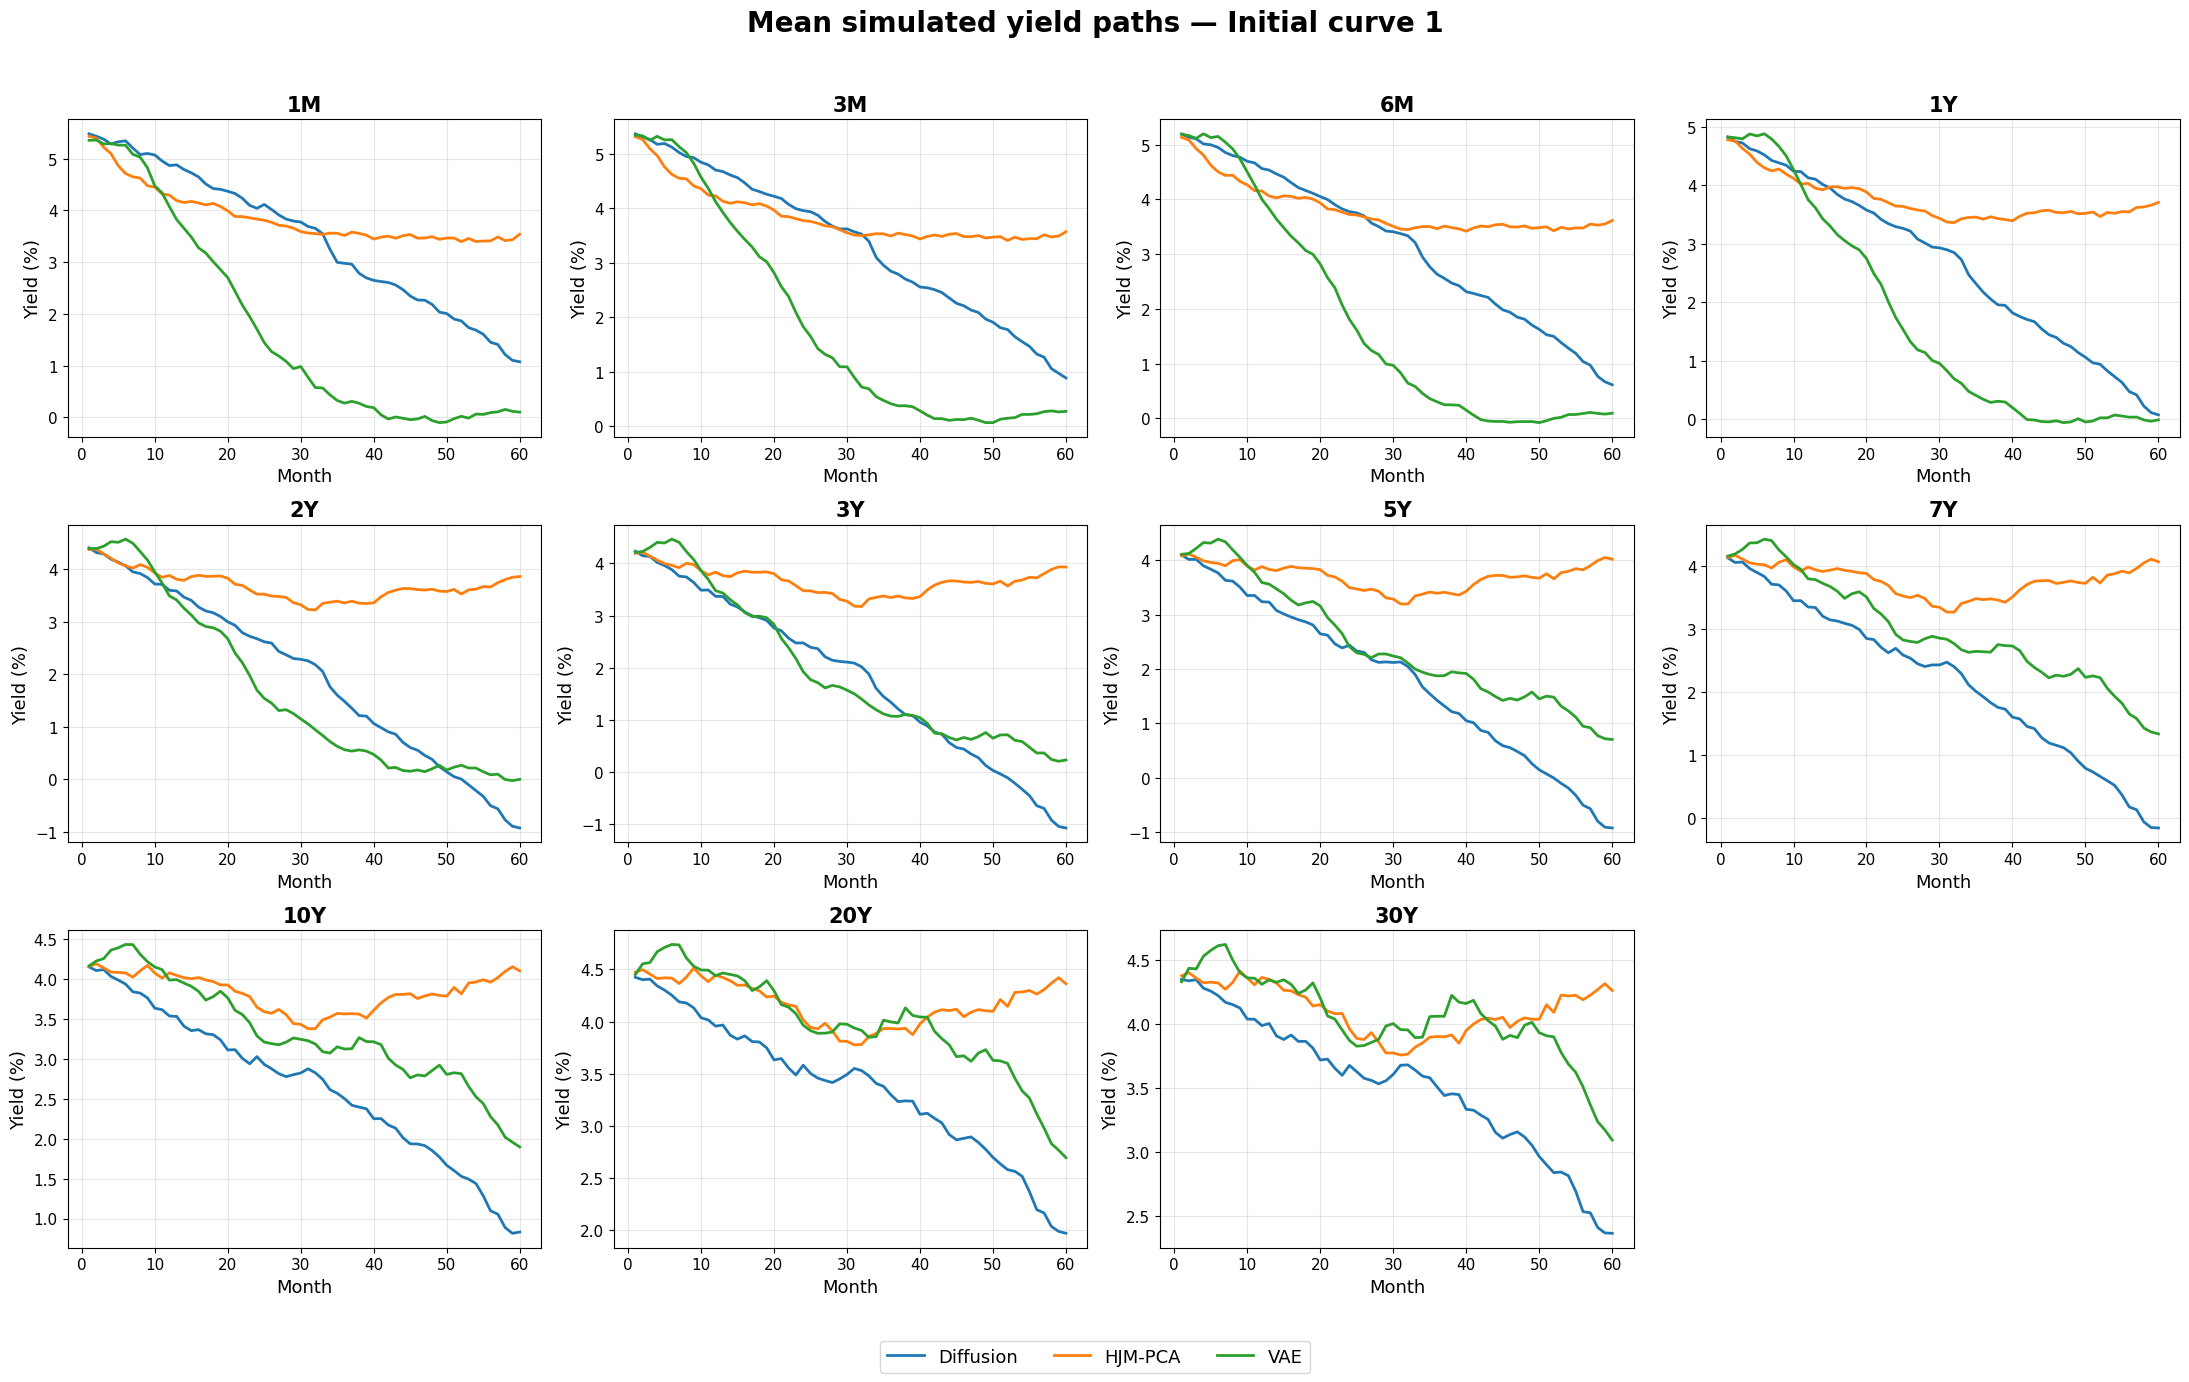

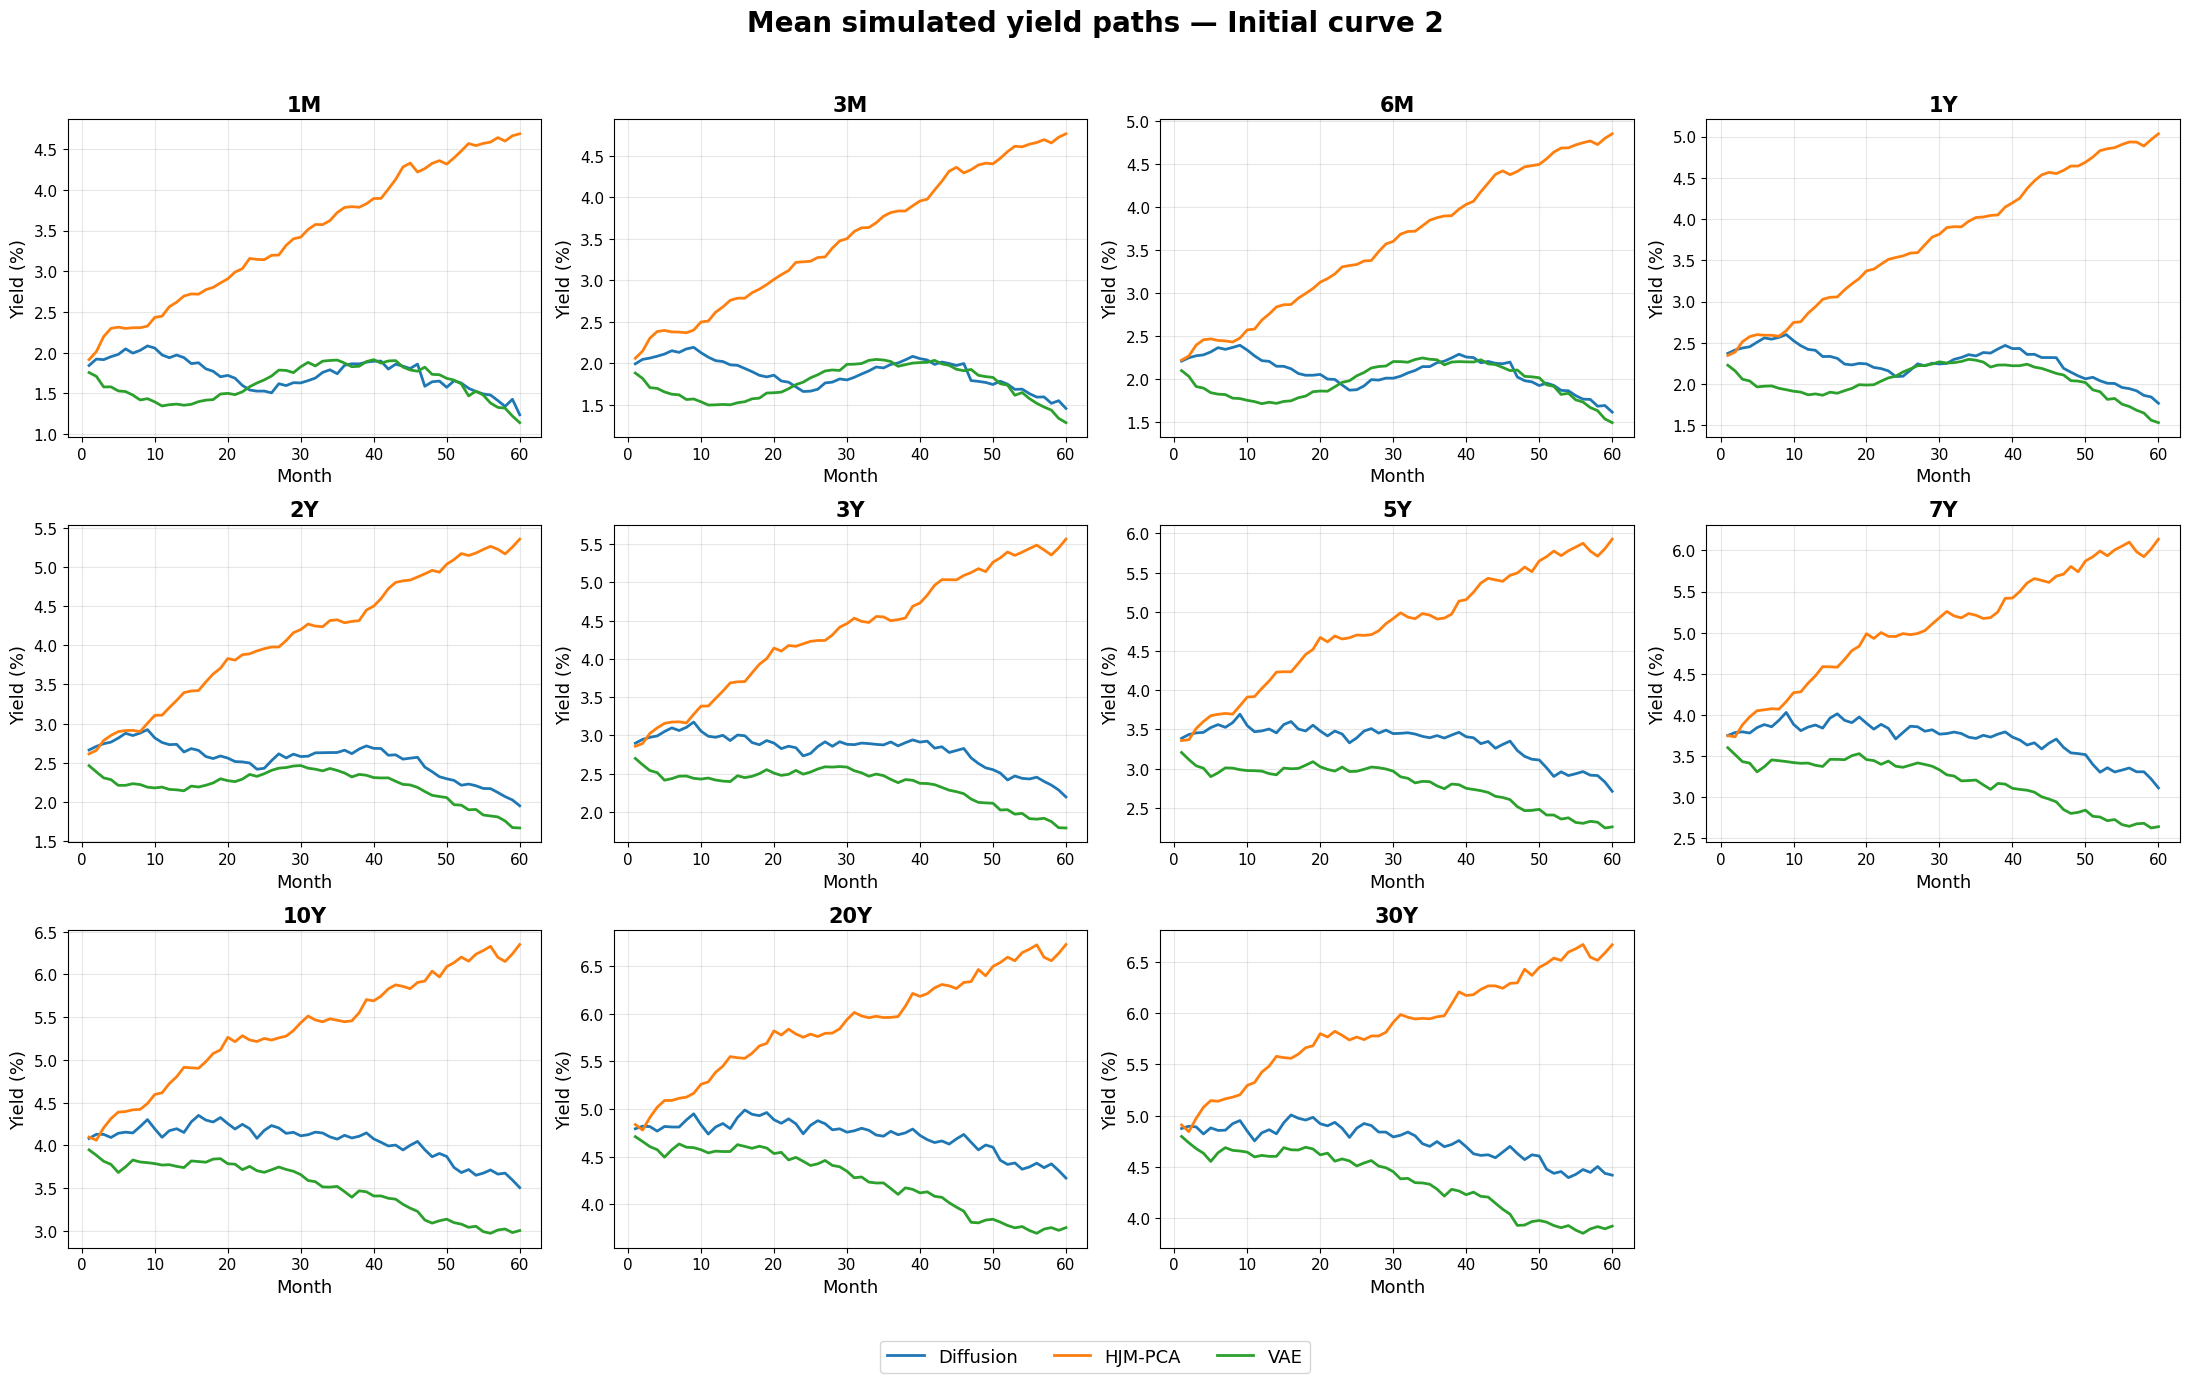

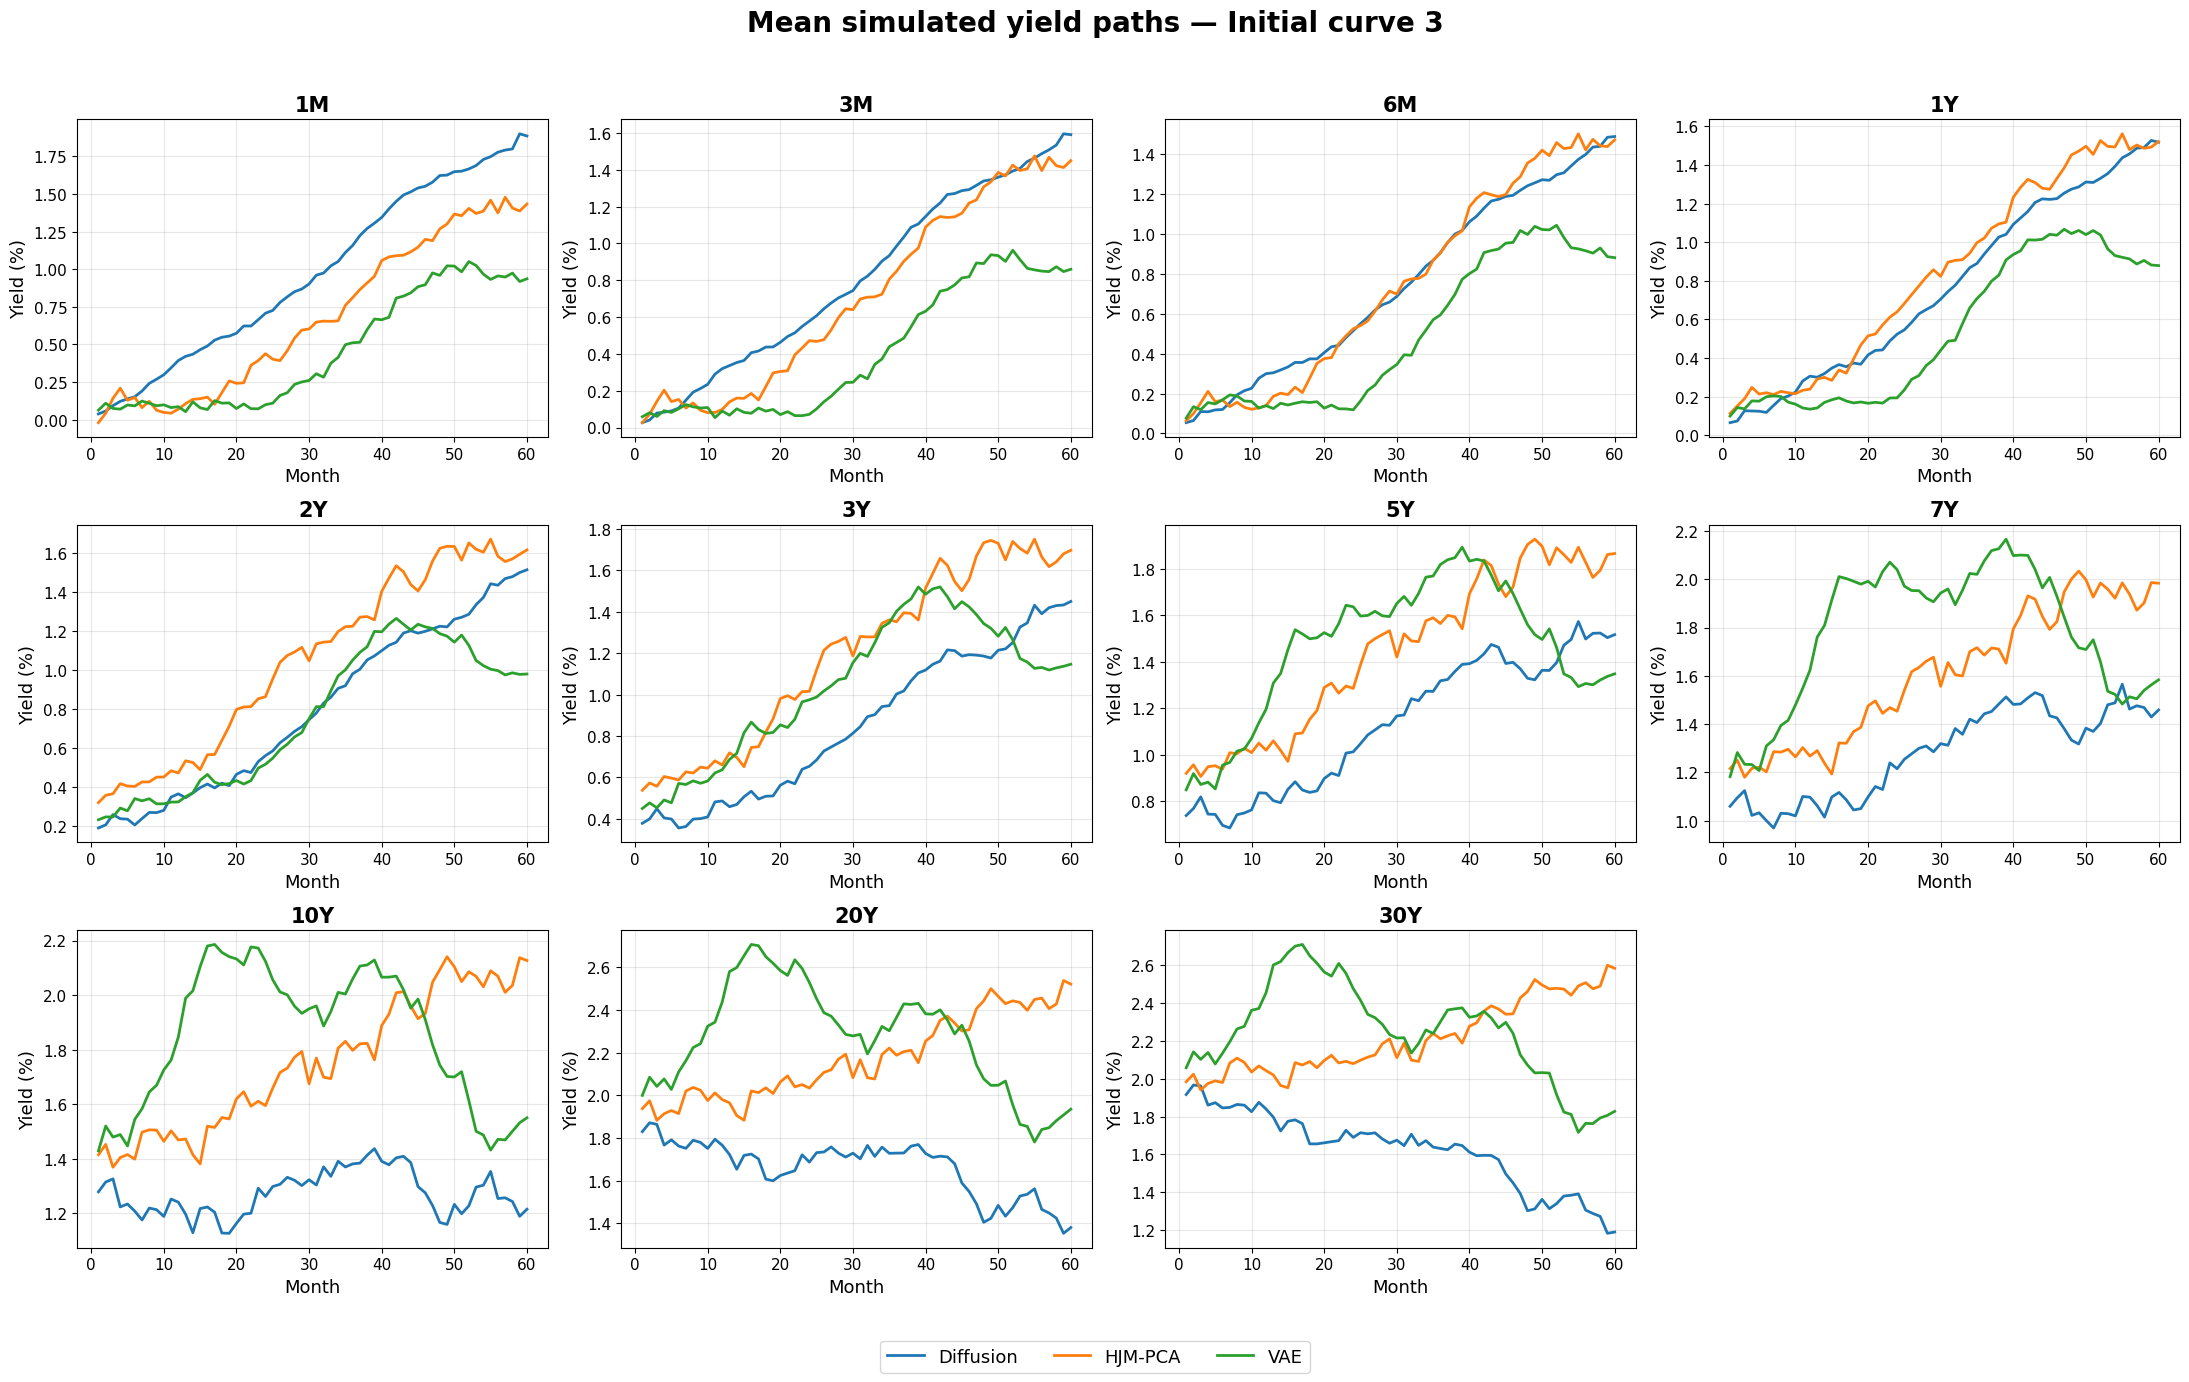

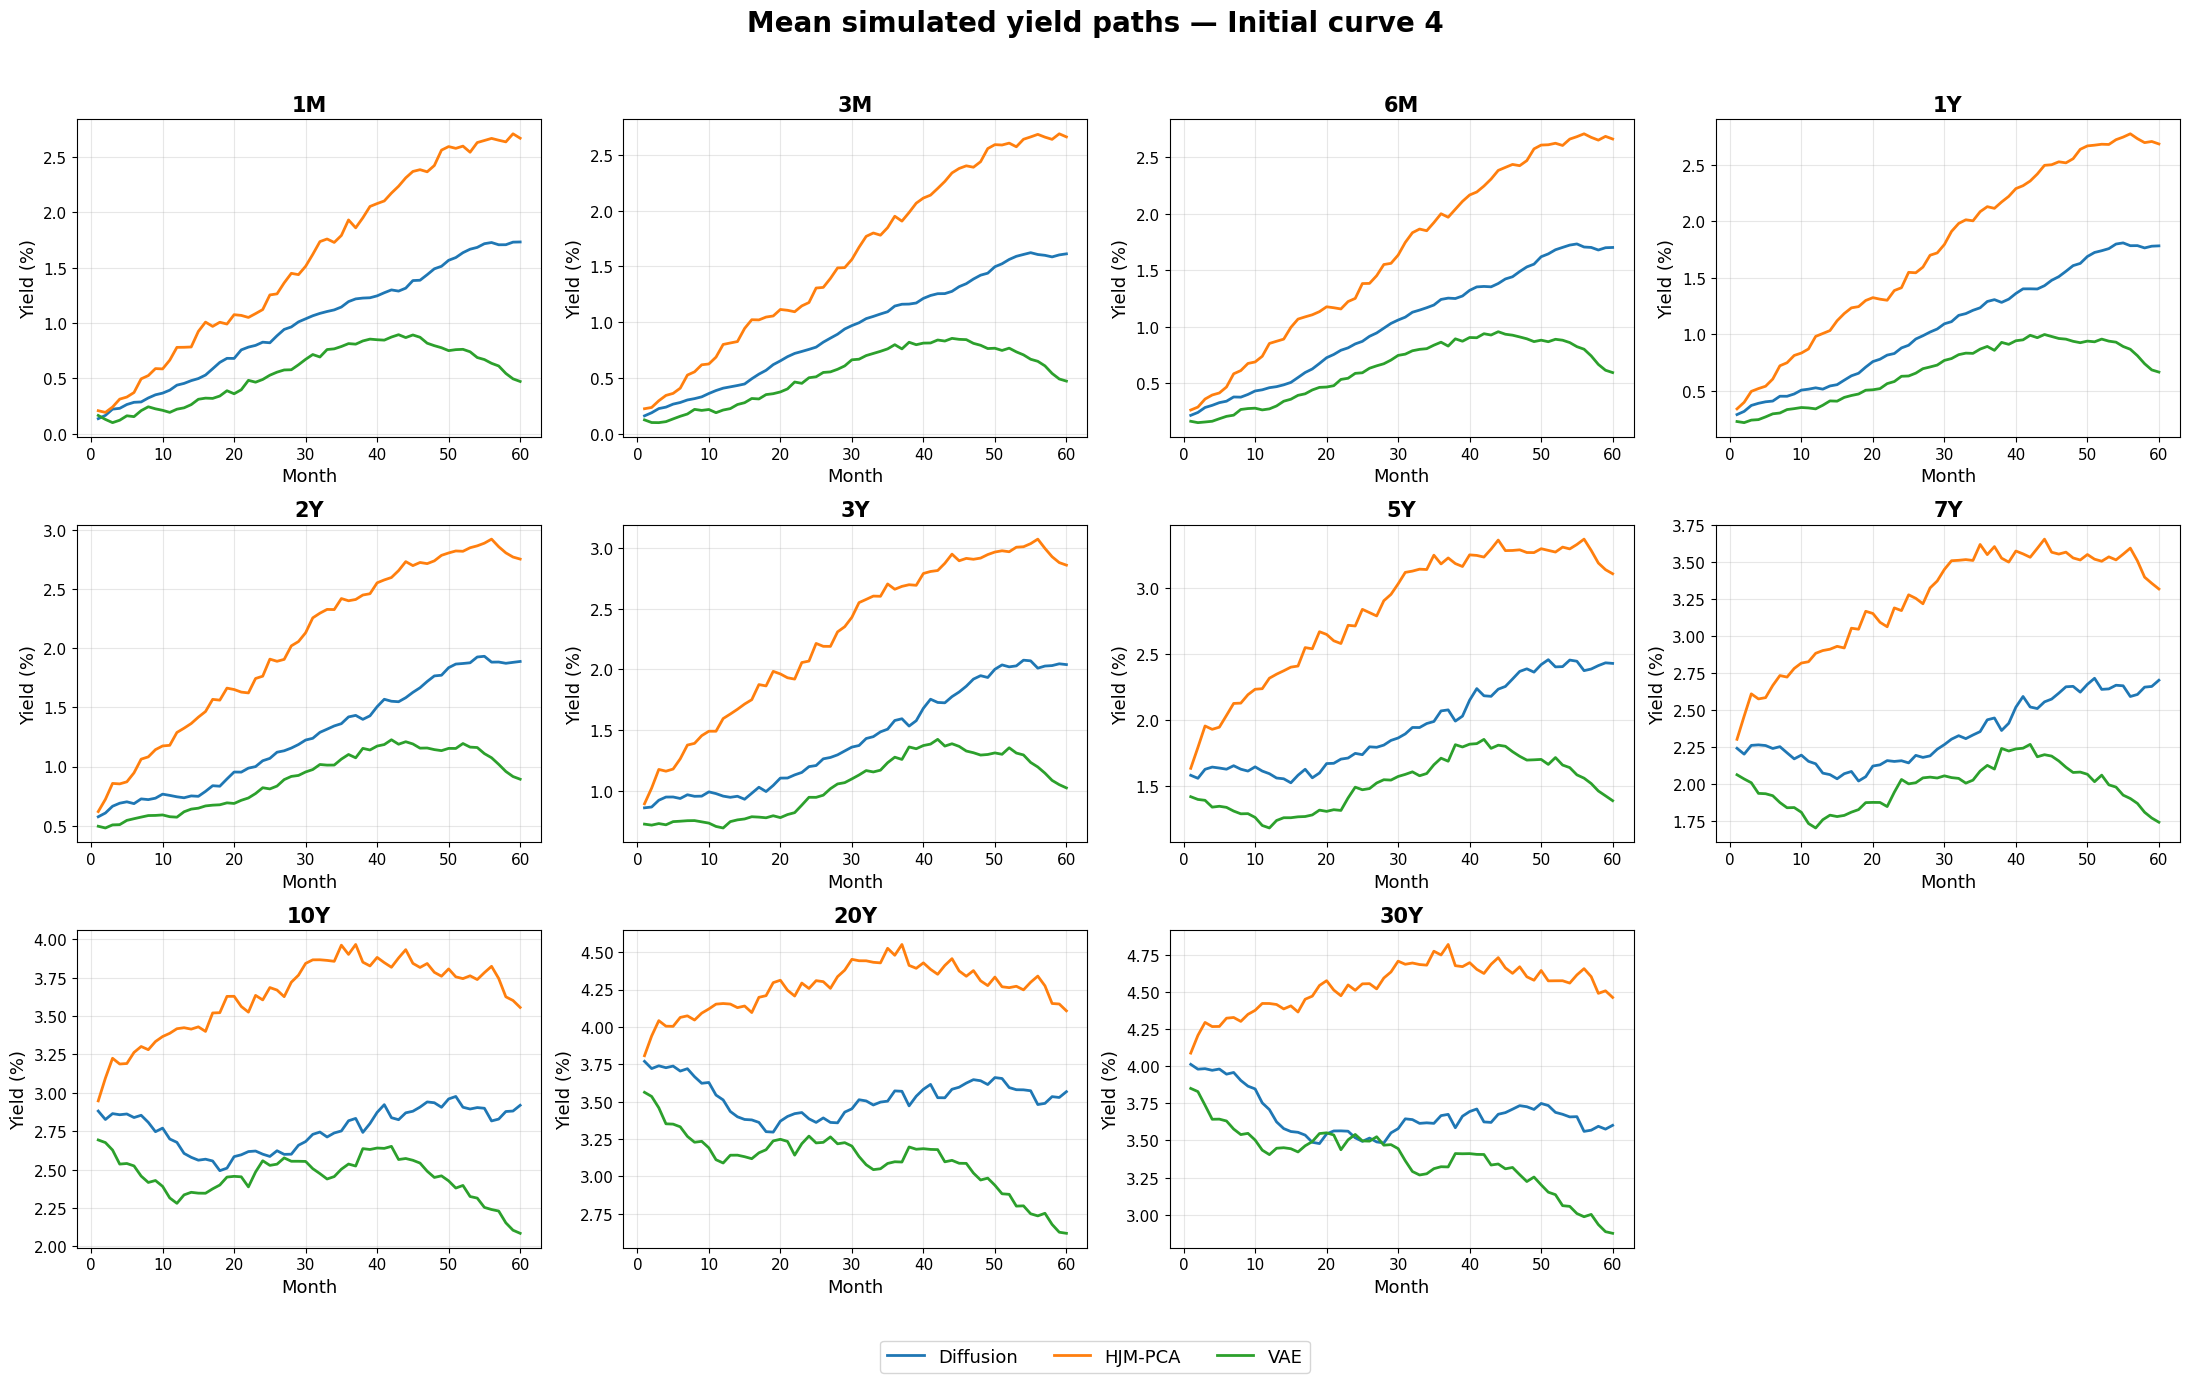

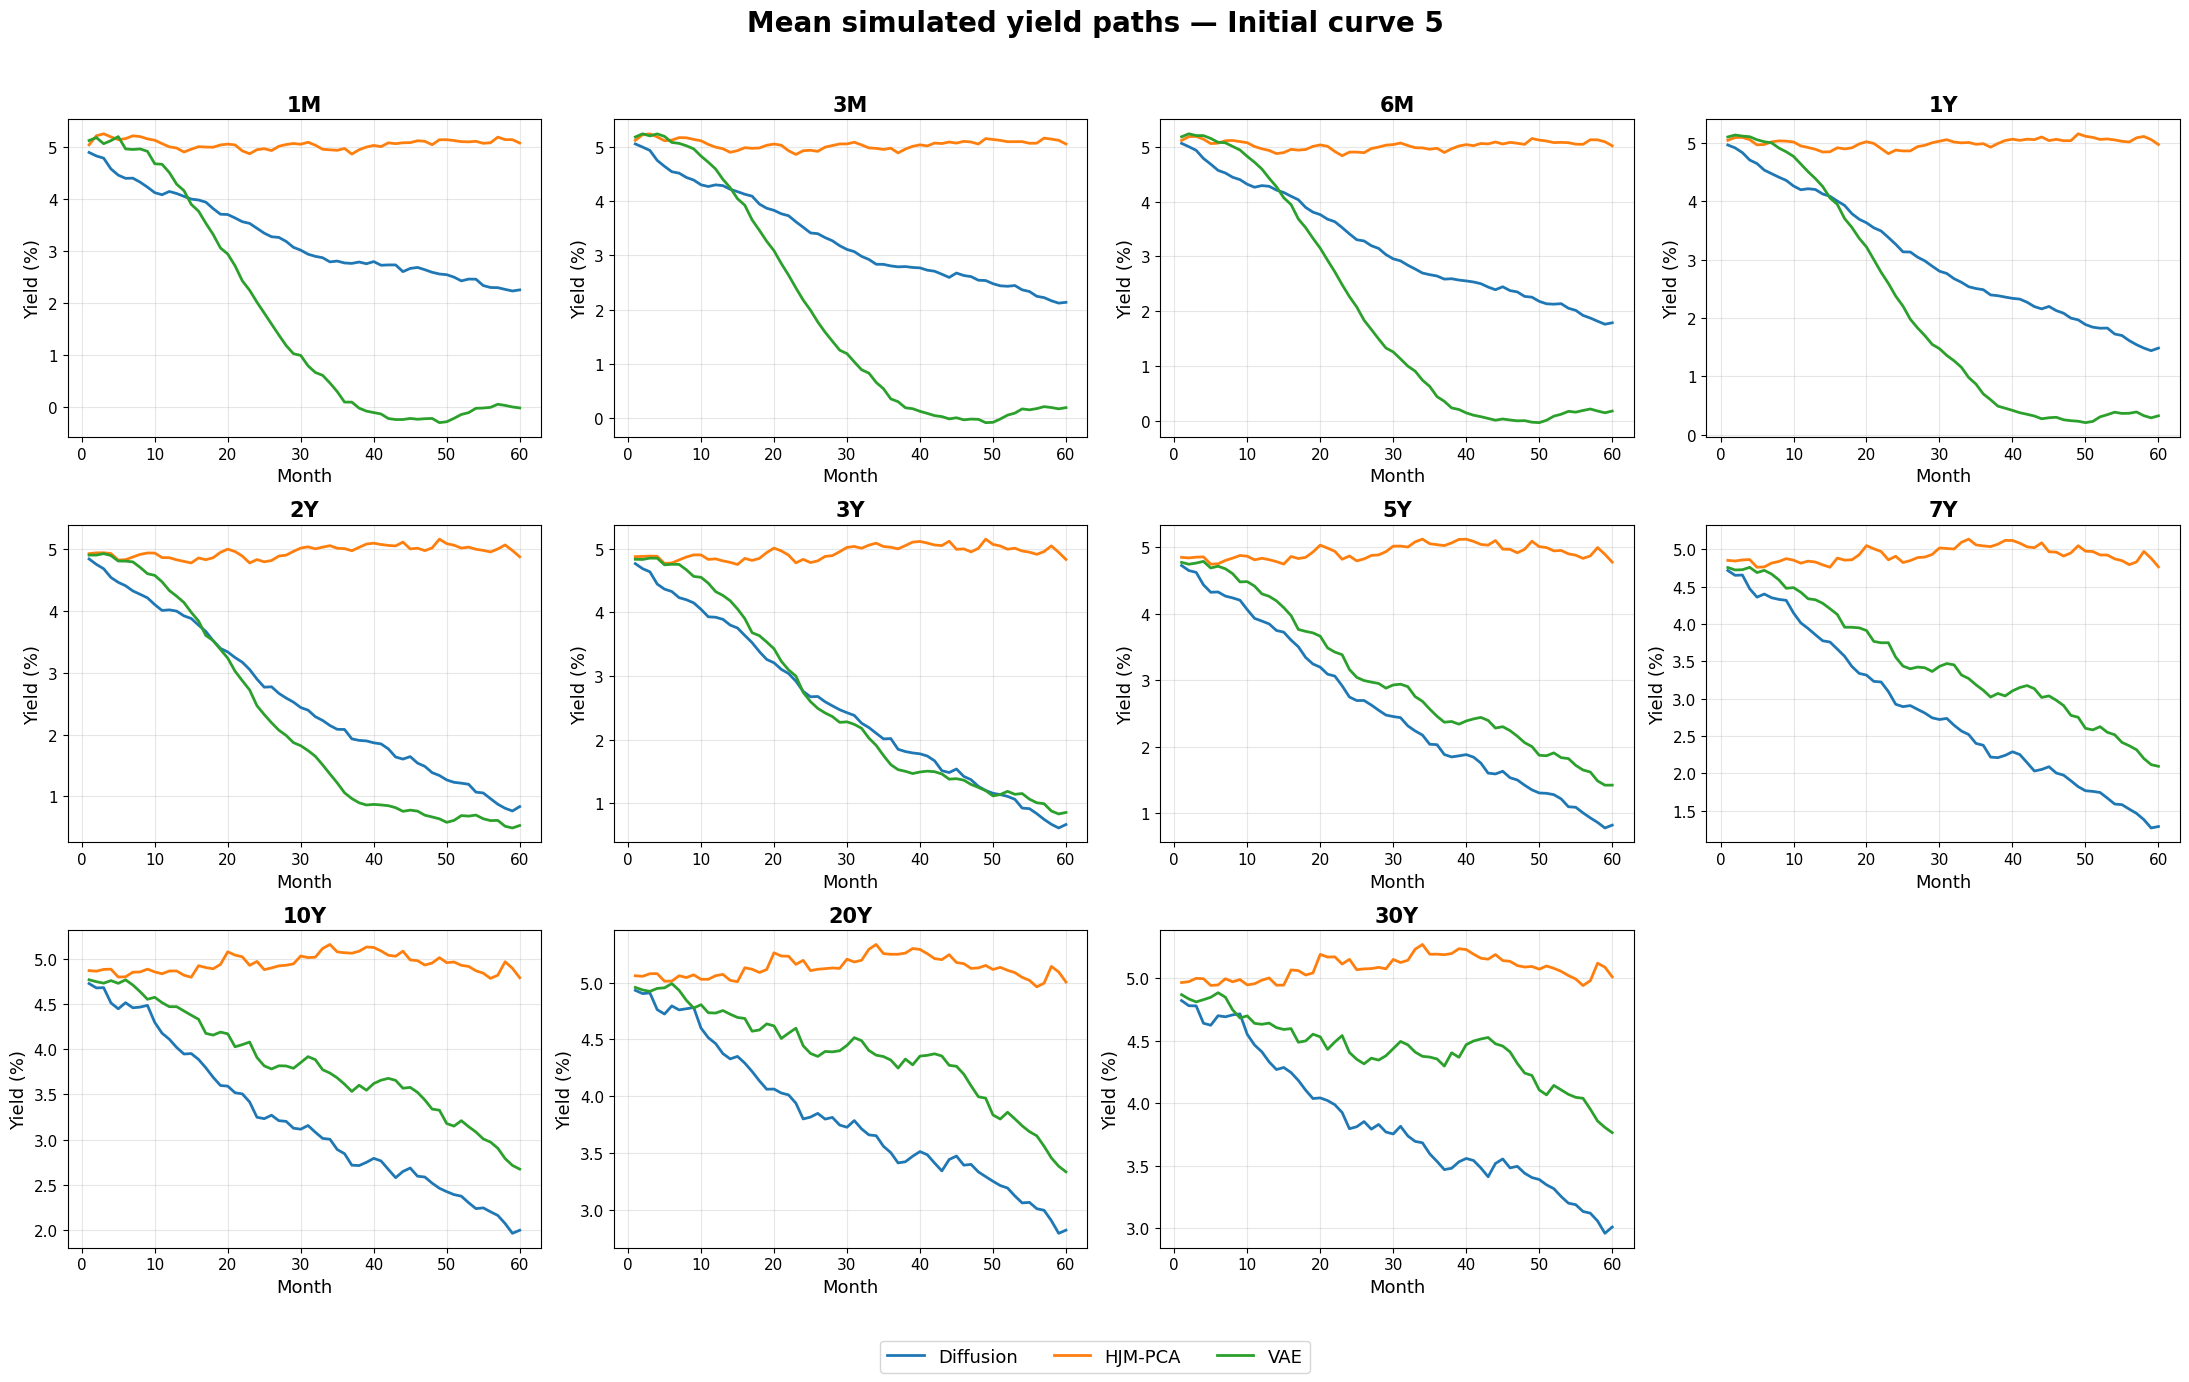

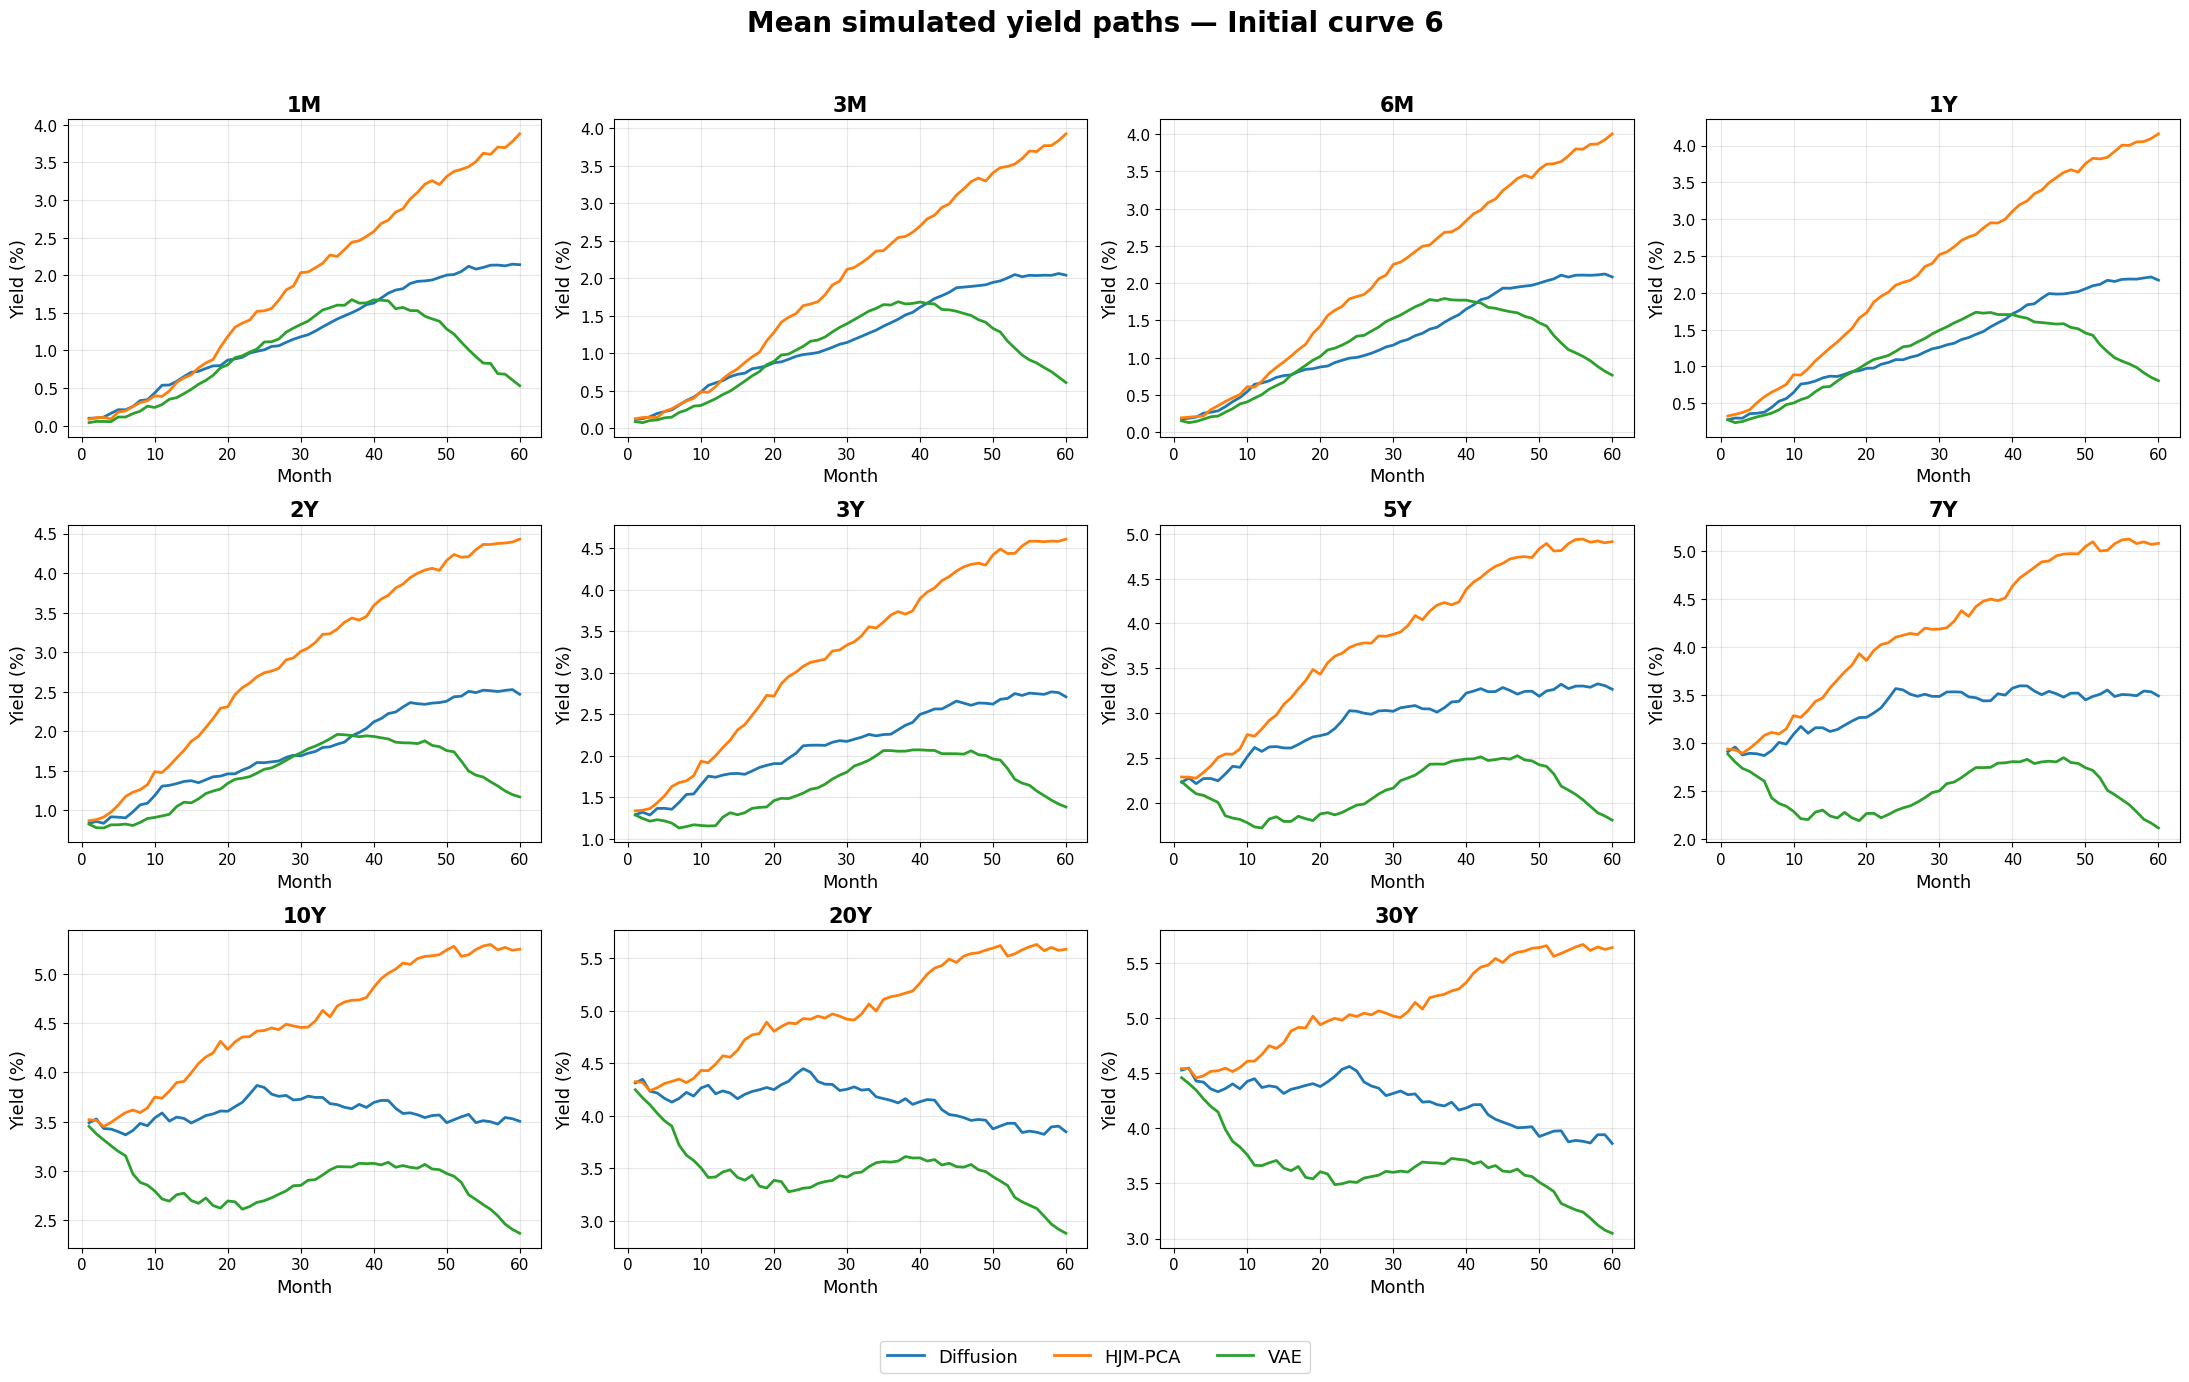

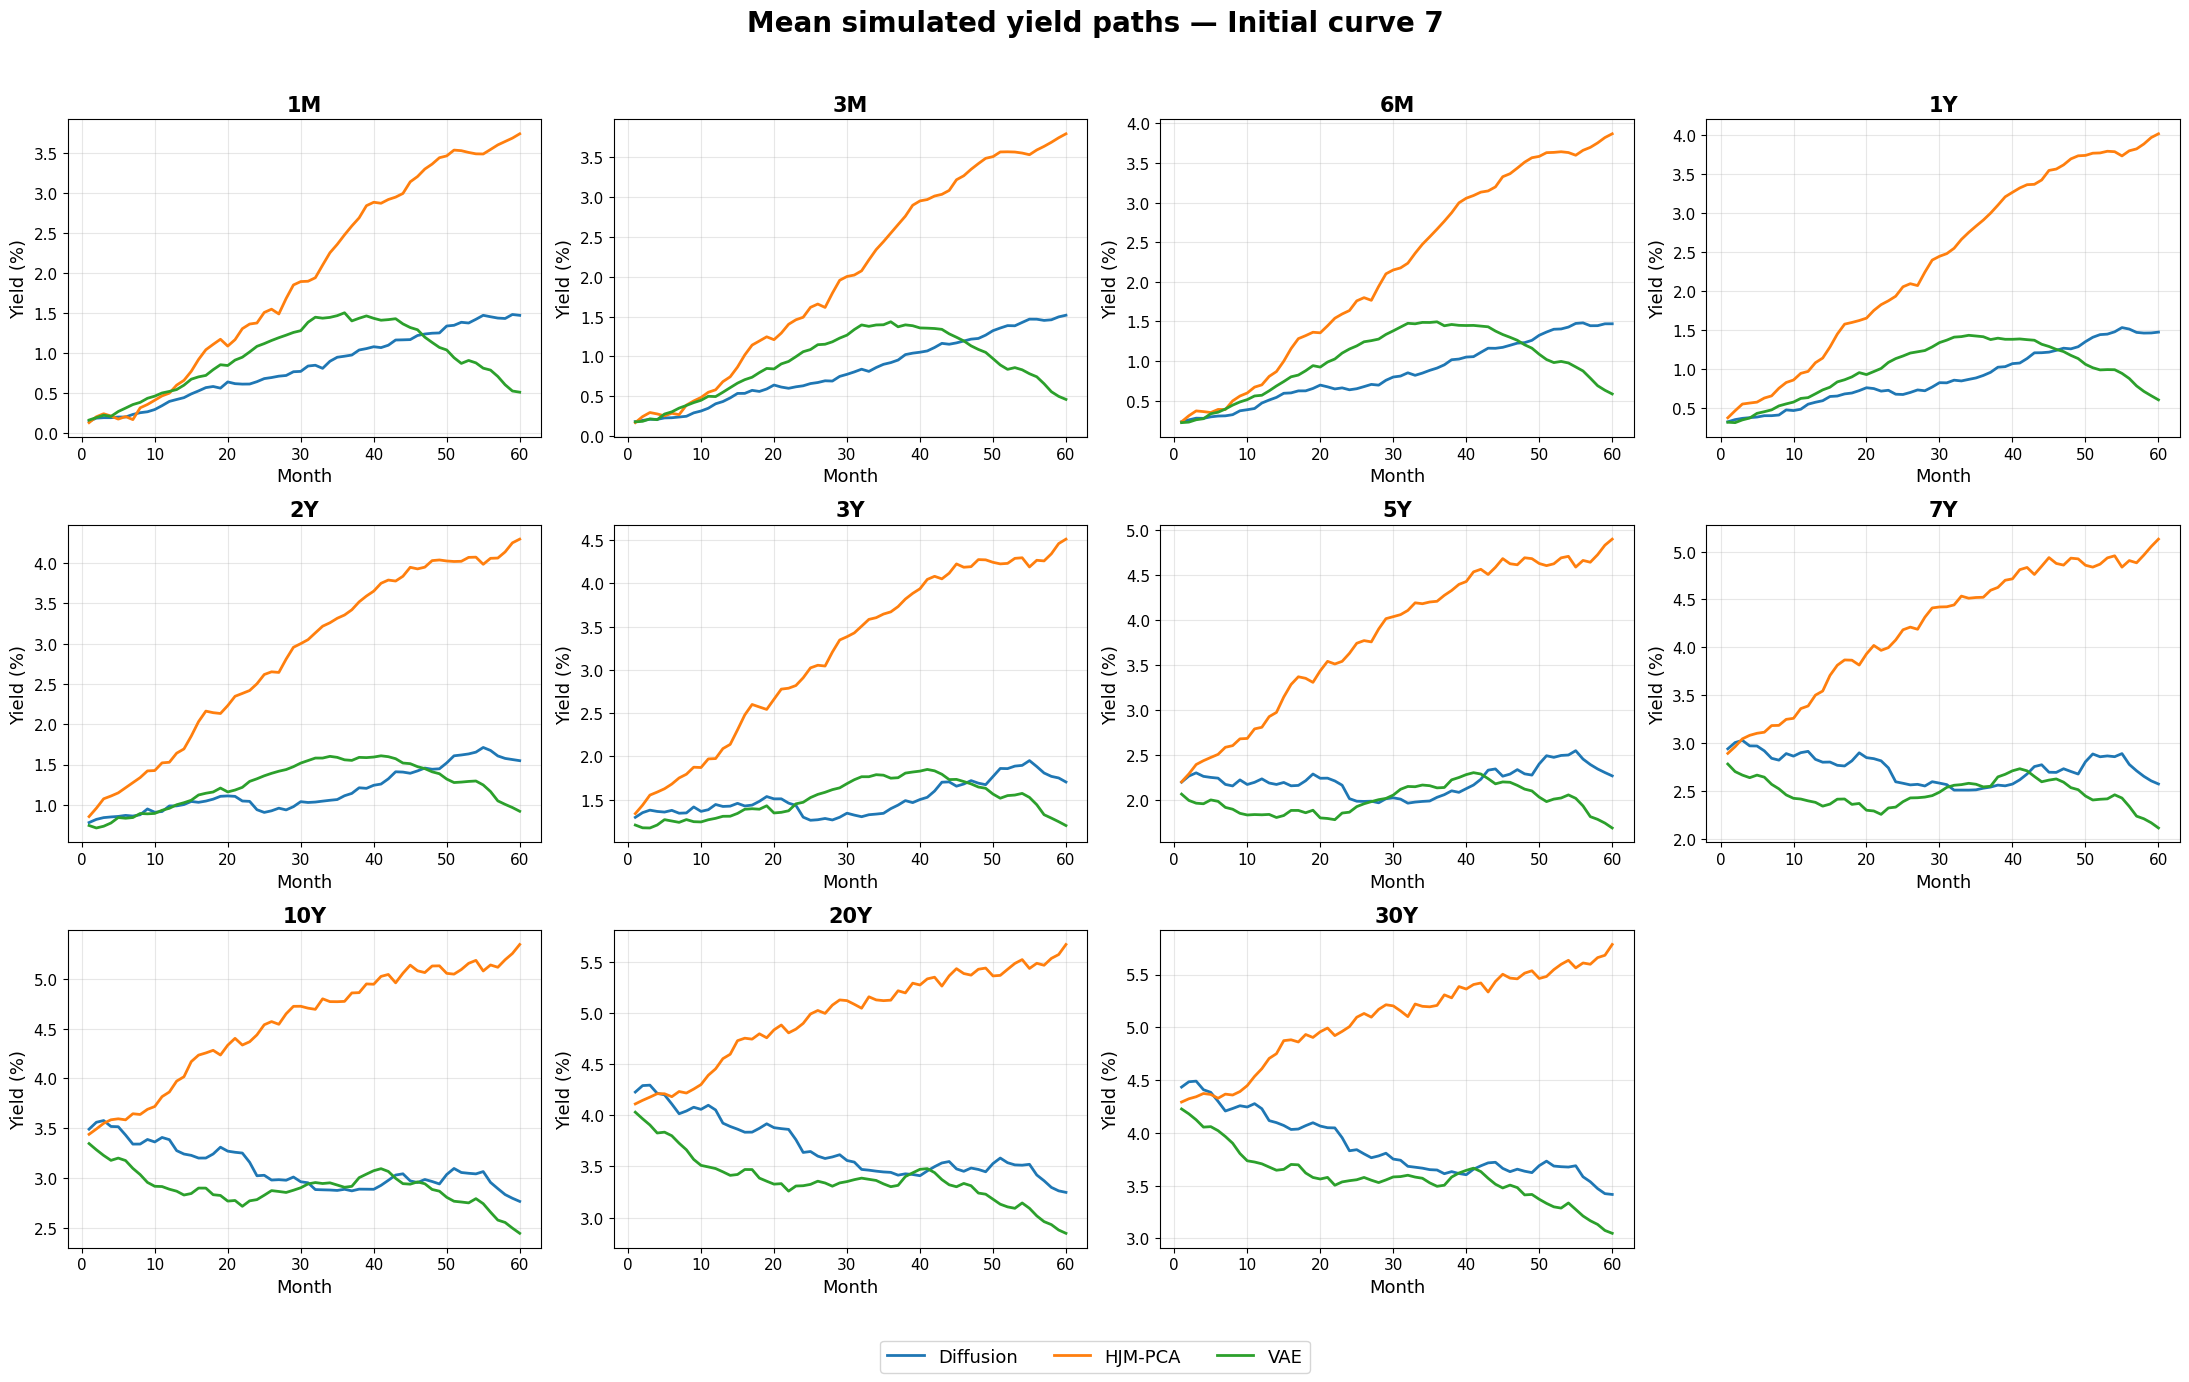

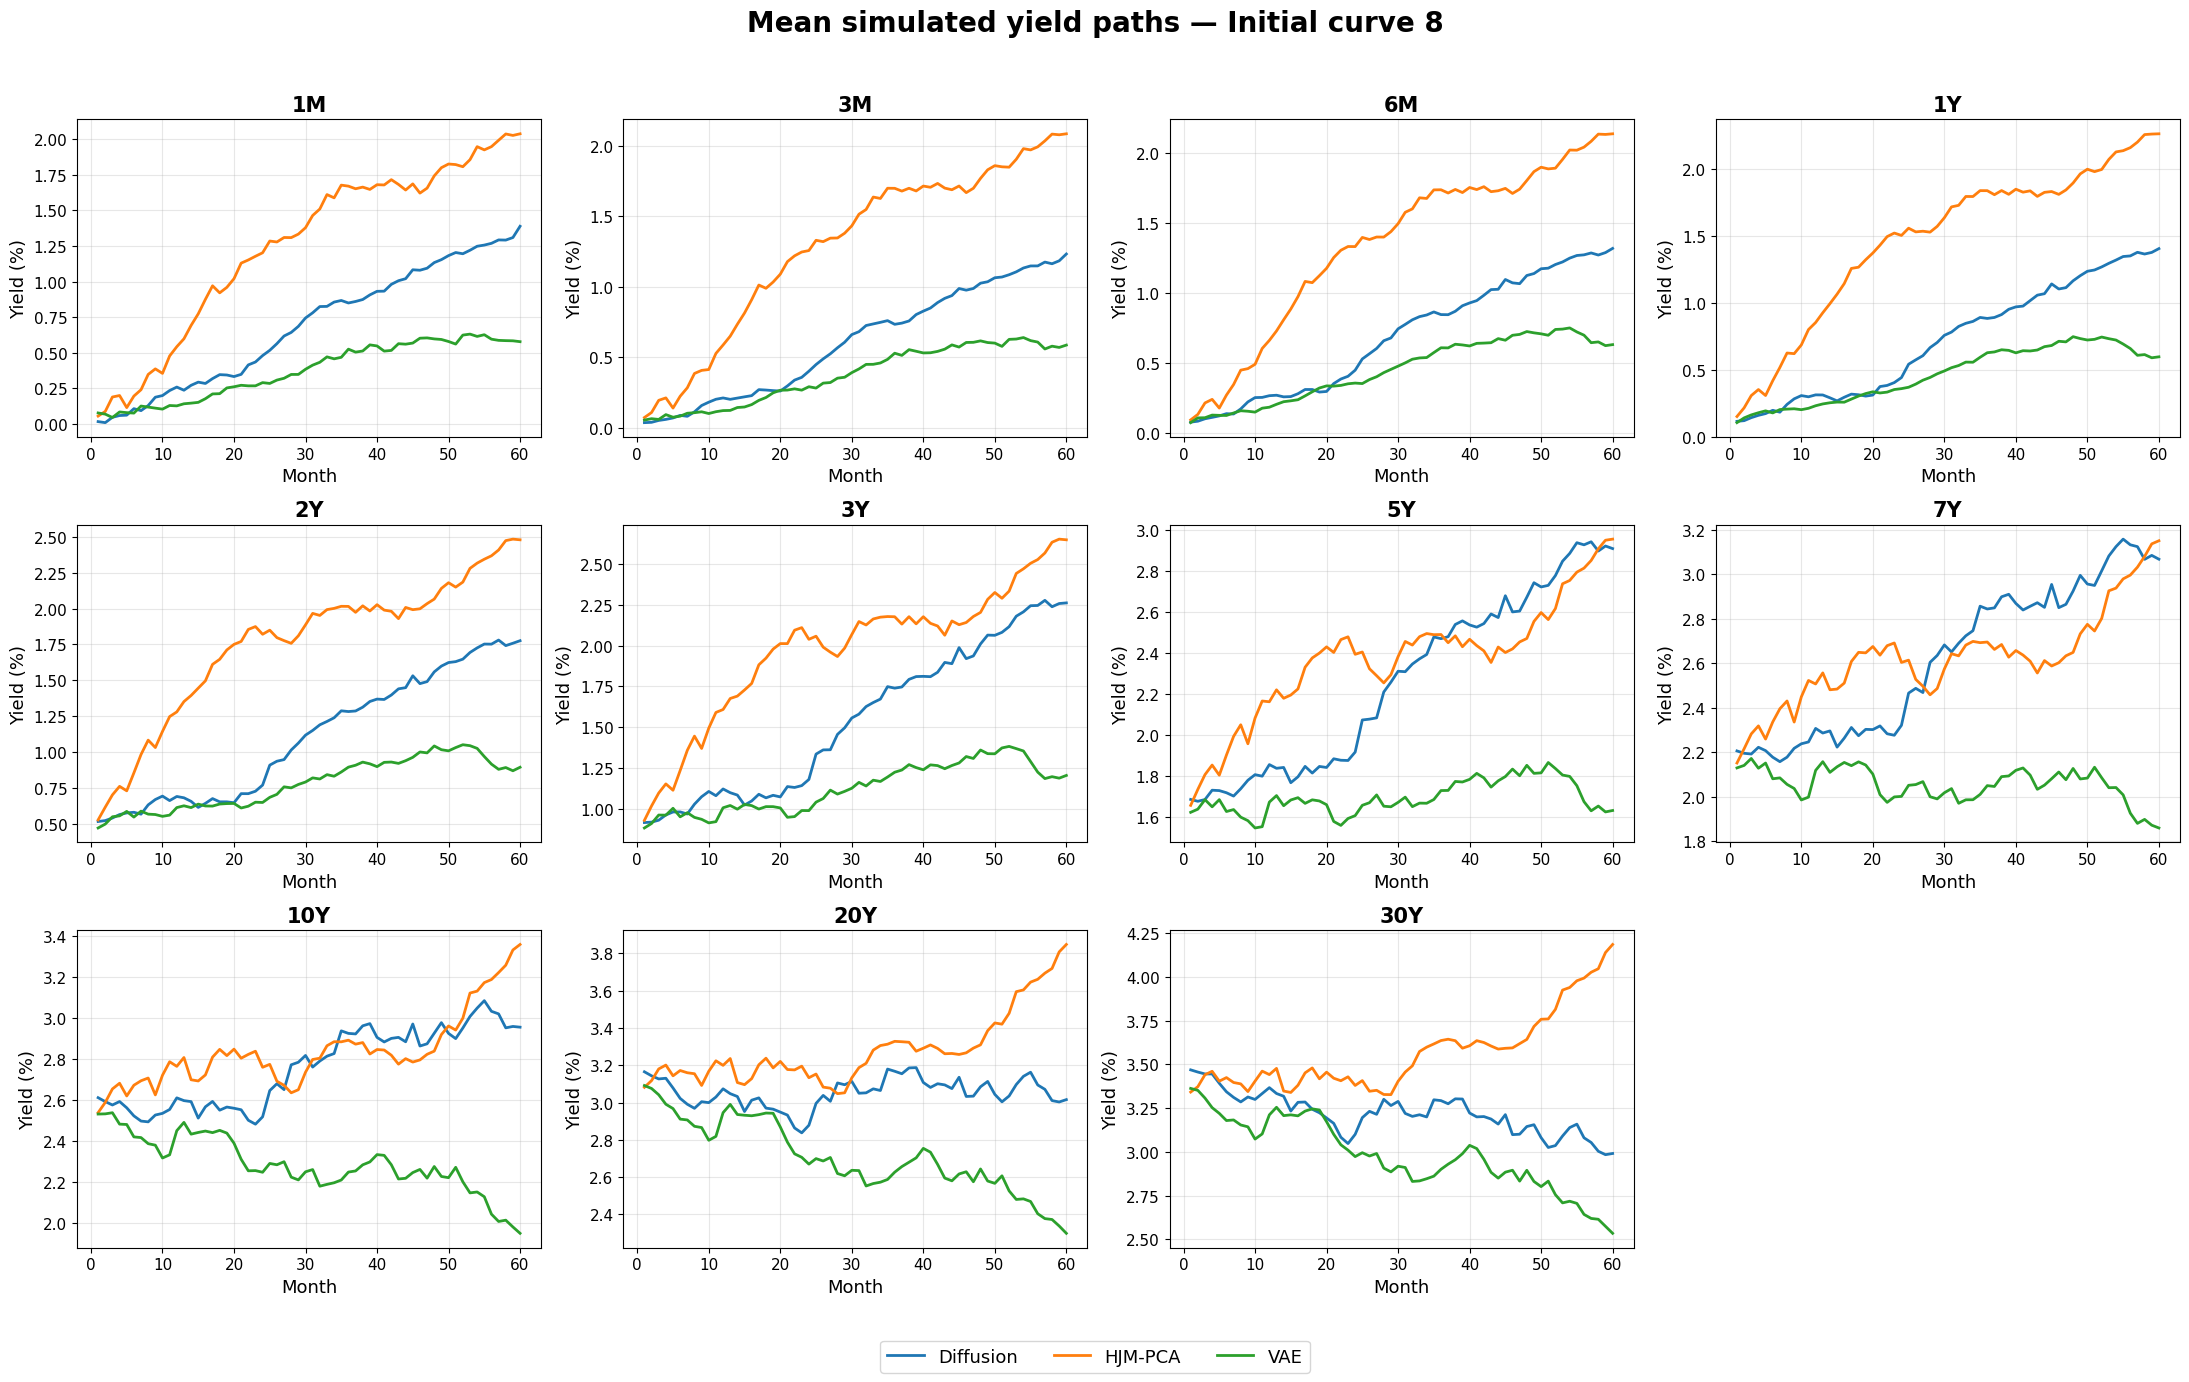

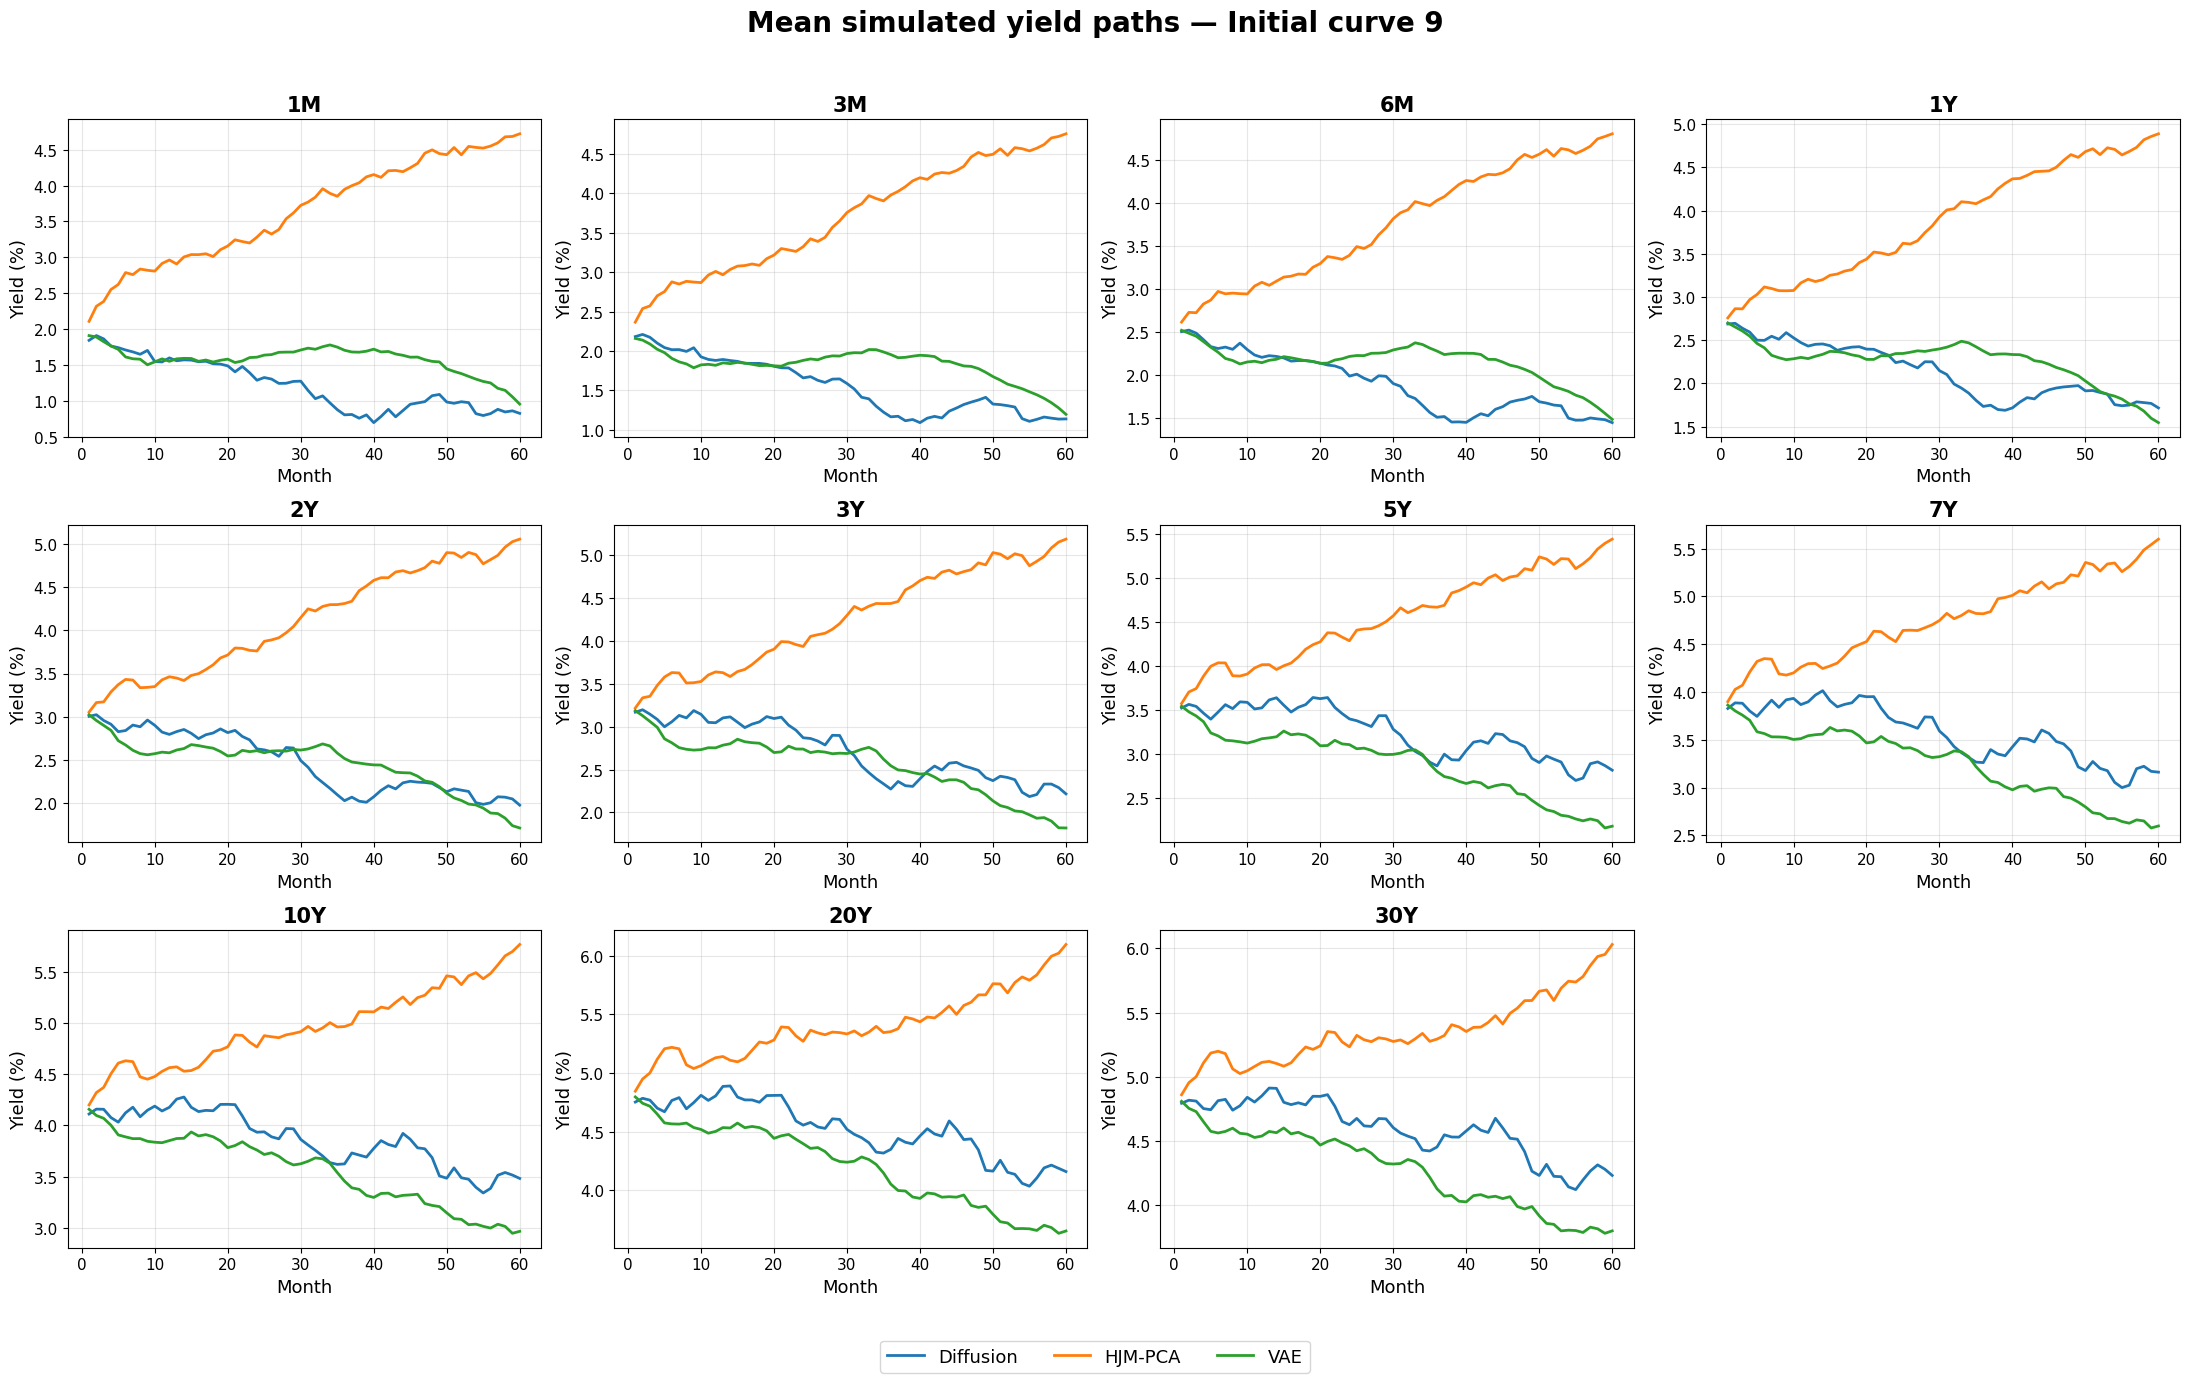

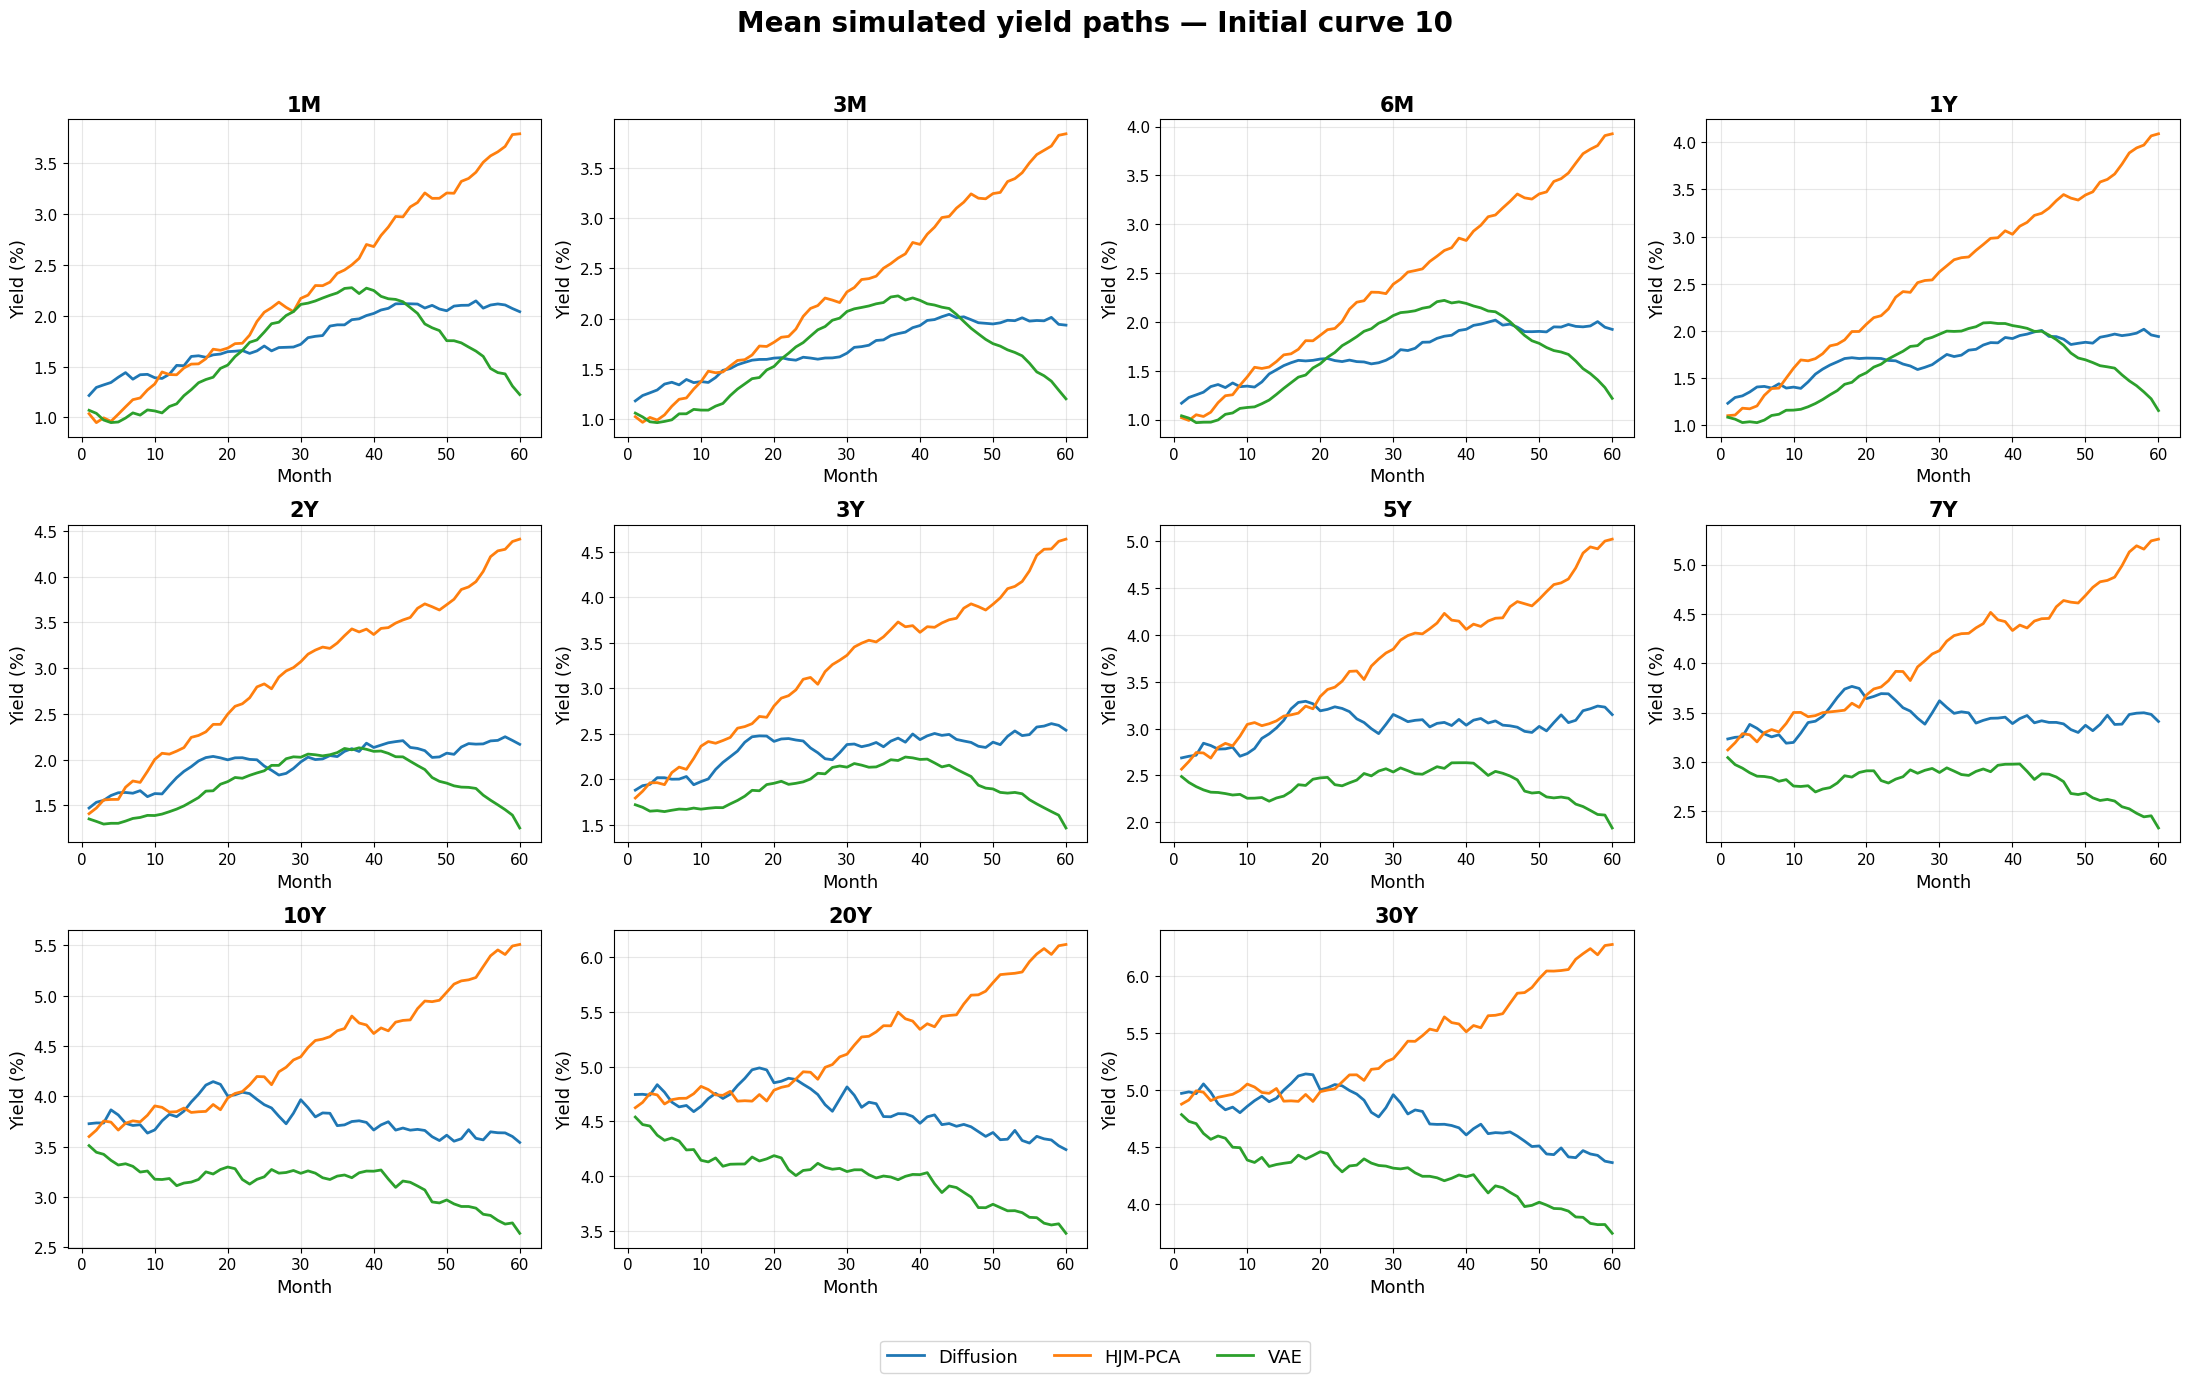

In [21]:
def plot_mean_paths_for_start_curve(start_curve_id, months_to_plot=None):
    fig, axes = plt.subplots(3, 4, figsize=(22, 14))
    axes = axes.flatten()

    for maturity_idx, maturity_label in enumerate(MATURITY_LABELS):
        ax = axes[maturity_idx]

        for model_name, df in SCENARIO_DATA.items():
            tensor, _ = scenario_tensor(df, start_curve_id)
            mean_path = tensor[:, :, maturity_idx].mean(axis=0)

            months = np.arange(1, len(mean_path) + 1)
            if months_to_plot is not None:
                mask = months <= months_to_plot
                months = months[mask]
                mean_path = mean_path[mask]

            ax.plot(months, mean_path, label=model_name, linewidth=2)

        ax.set_title(maturity_label, fontsize=15, fontweight="bold")
        ax.set_xlabel("Month", fontsize=13)
        ax.set_ylabel("Yield (%)", fontsize=13)
        ax.tick_params(axis="both", labelsize=11)
        ax.grid(alpha=0.3)

    axes[-1].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=13)

    fig.suptitle(
        f"Mean simulated yield paths — Initial curve {start_curve_id}",
        fontsize=20,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()


for start_id in START_CURVE_IDS:
    plot_mean_paths_for_start_curve(start_id)


## Volatiliteit per looptijd

De volatiliteit wordt berekend als de standaardafwijking van maandelijkse eerste verschillen, afzonderlijk per scenario. Daarna wordt gemiddeld over de scenario's.


1-10, ga naar volgende cel voor splitsing: 1-6 en 7-10

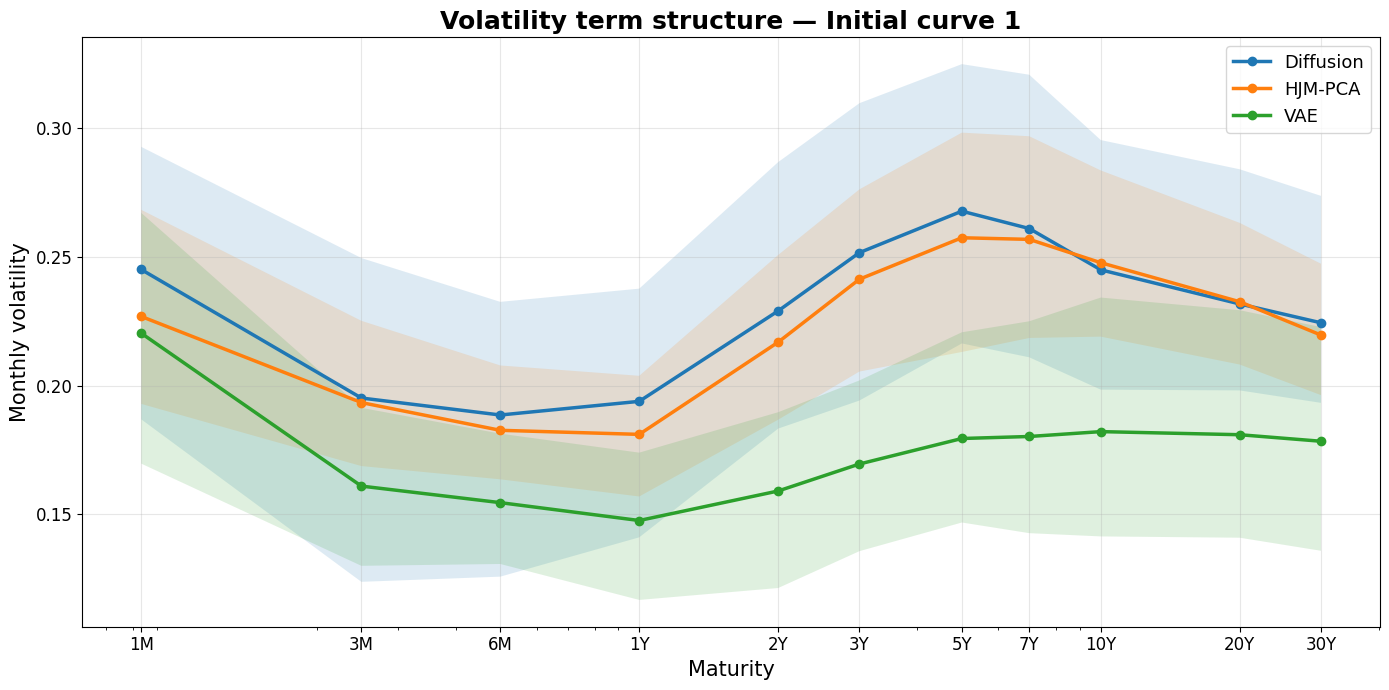

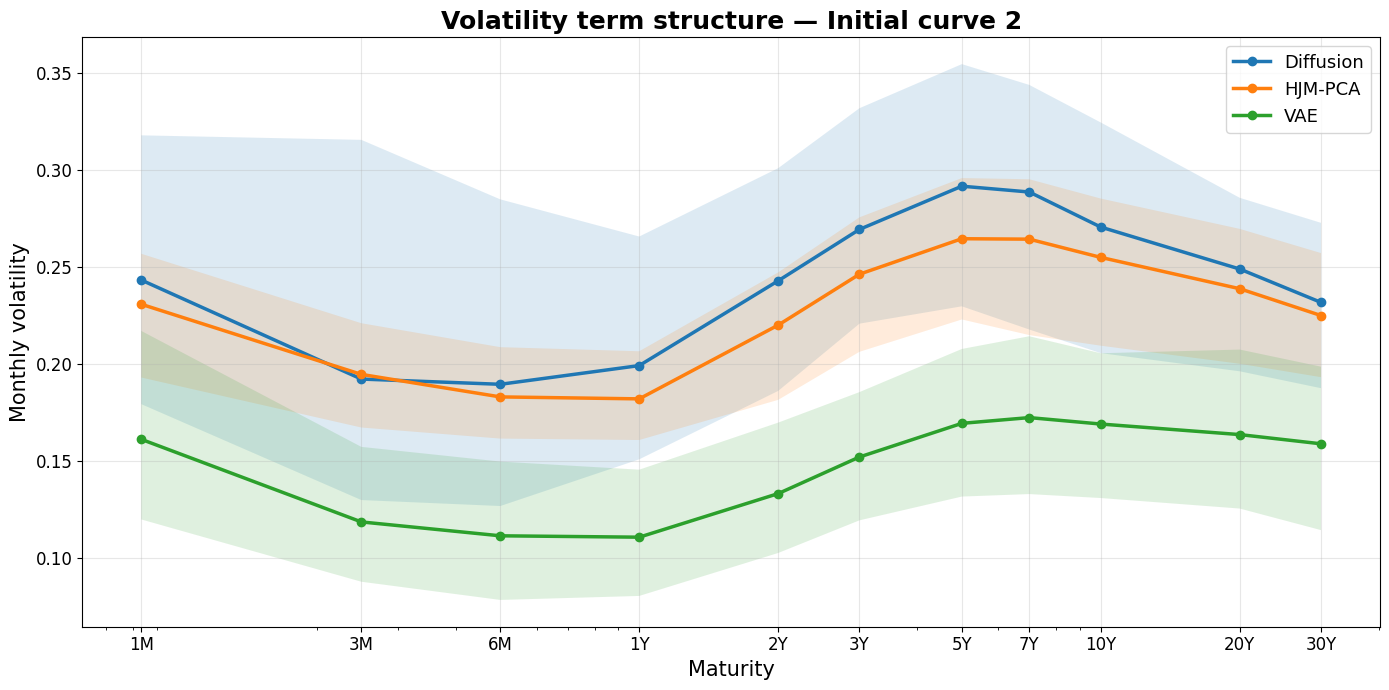

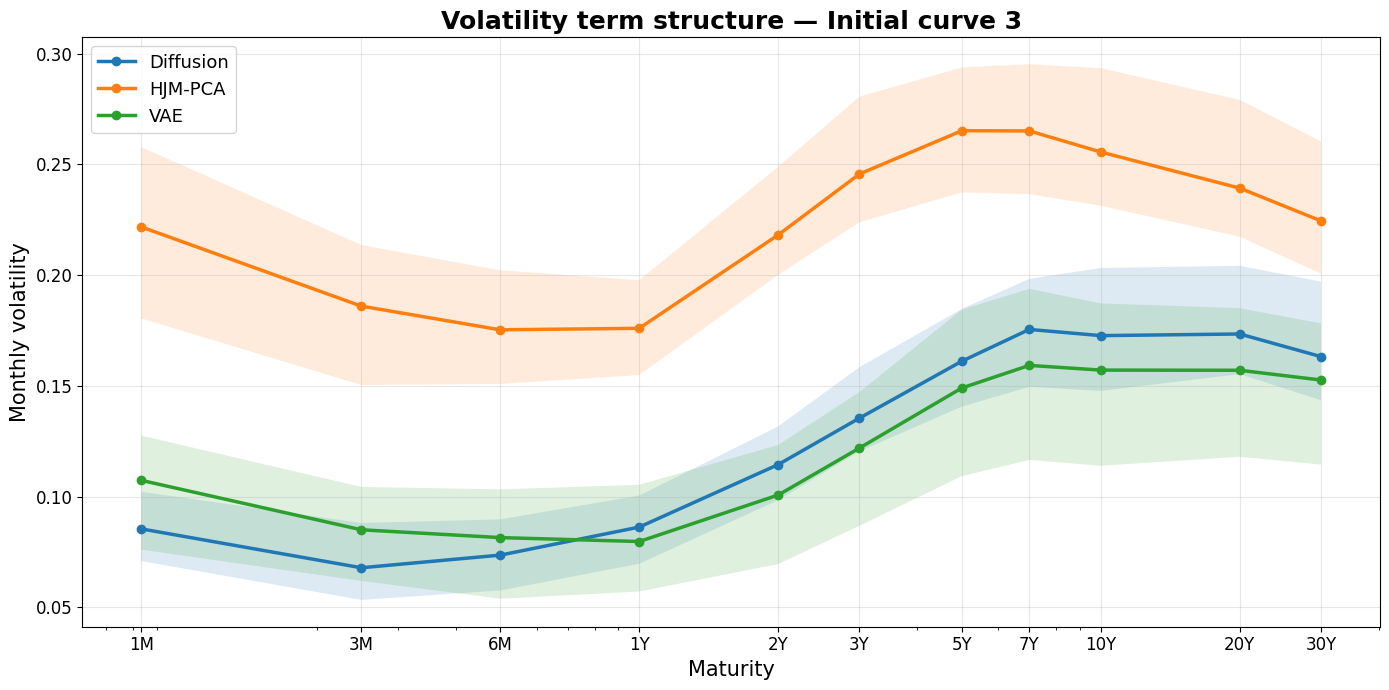

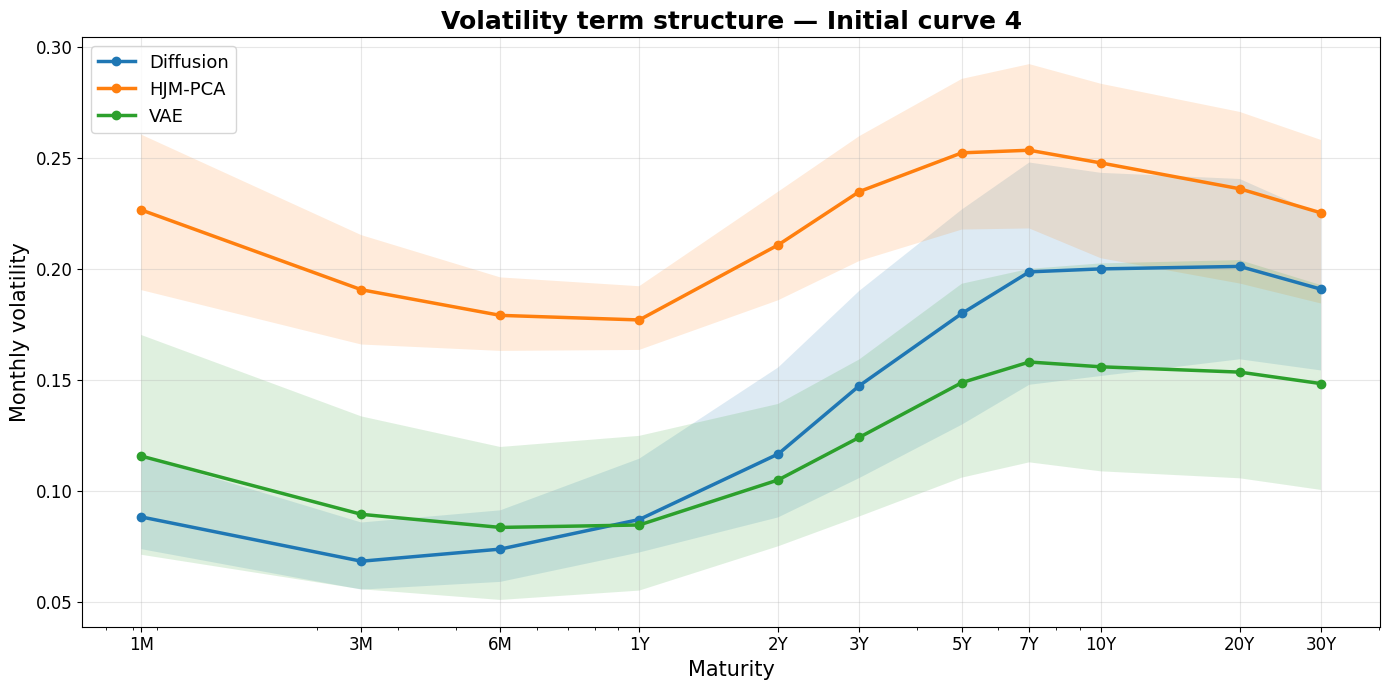

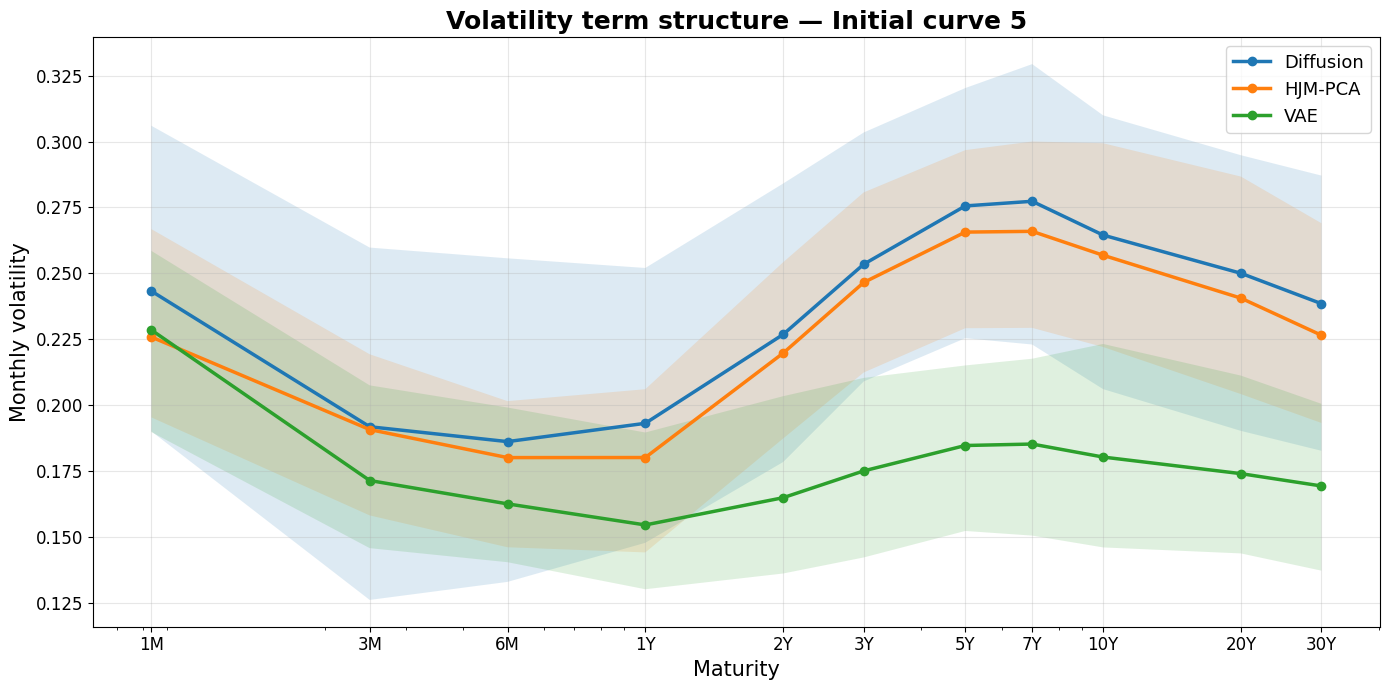

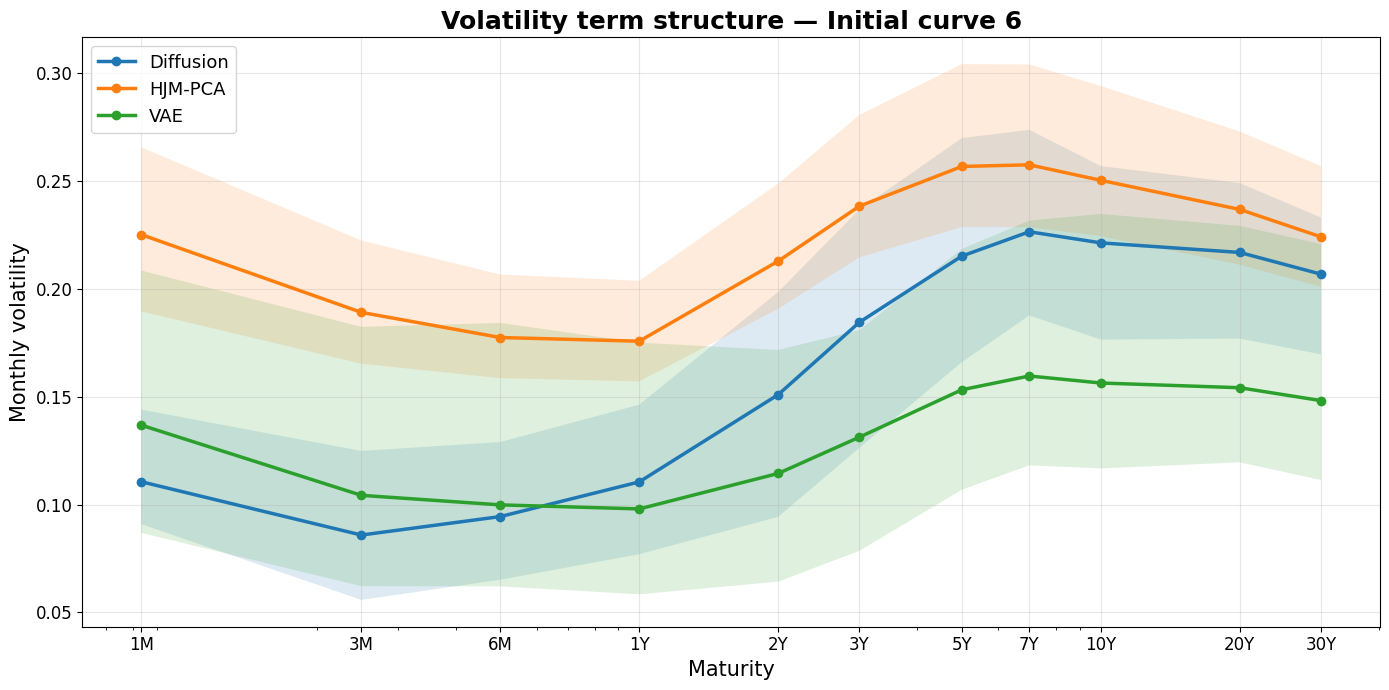

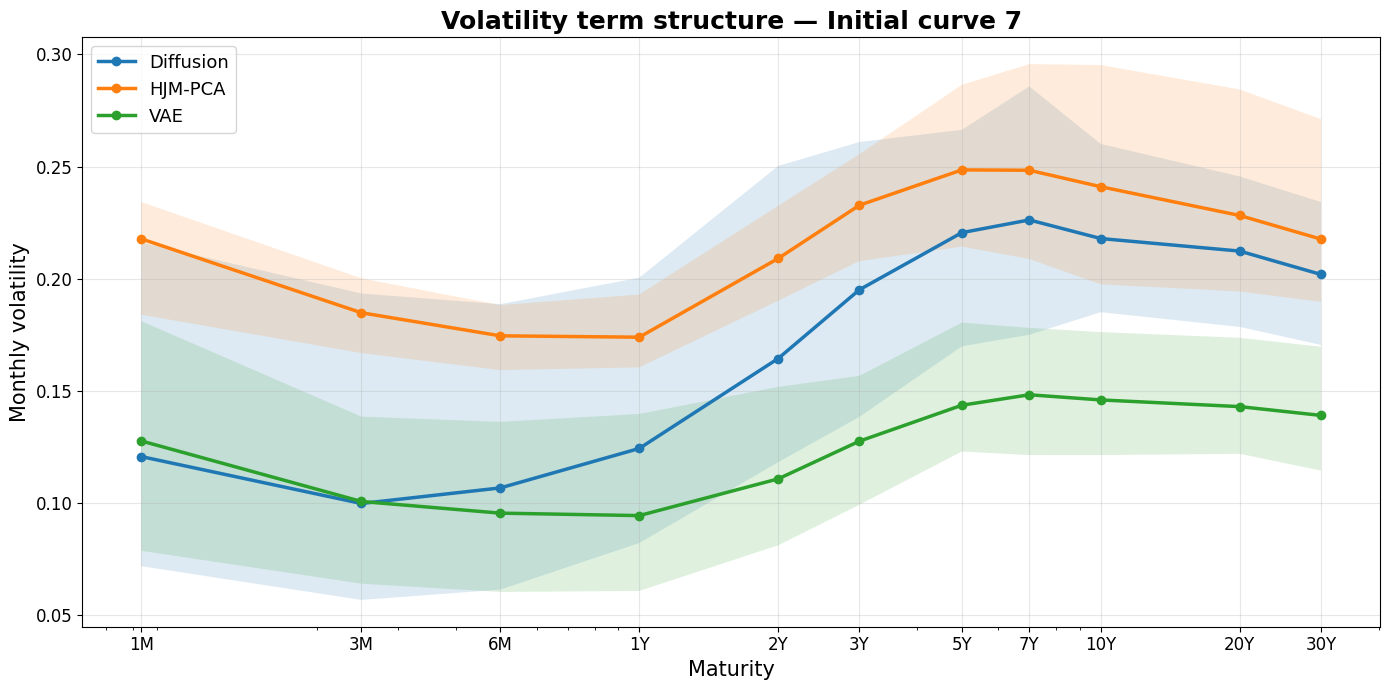

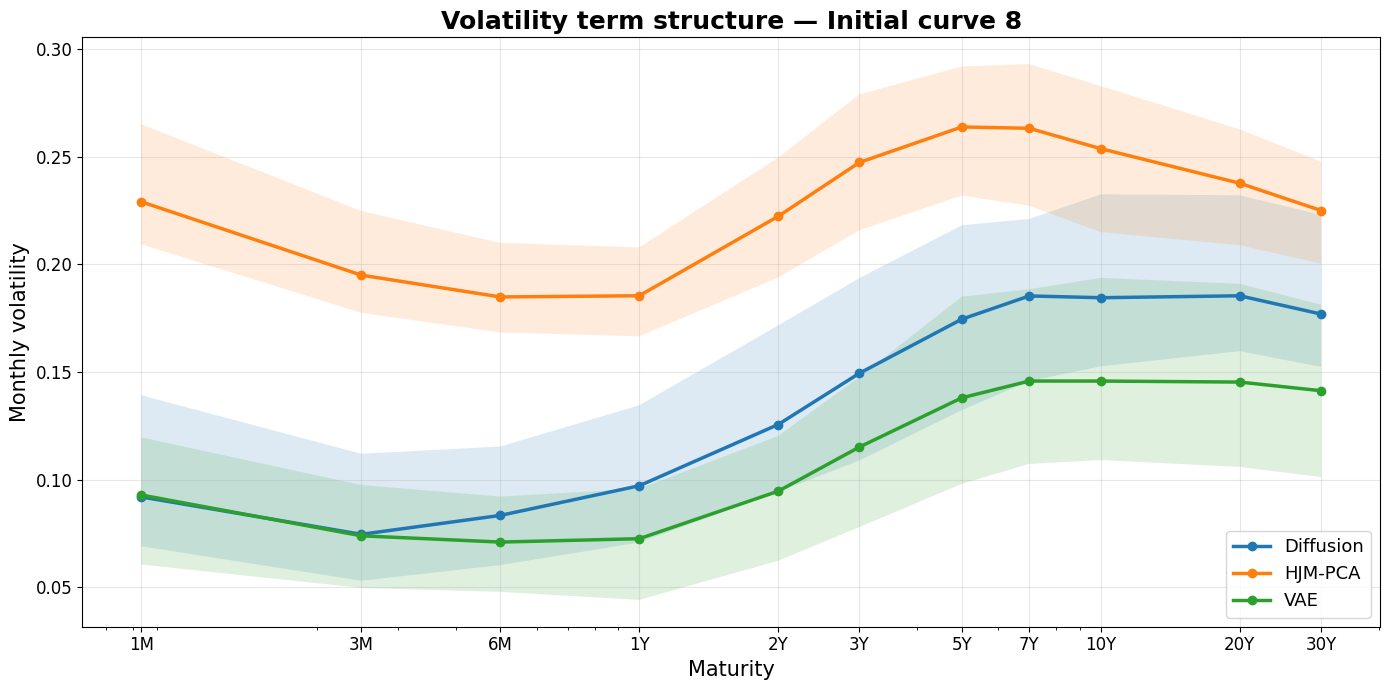

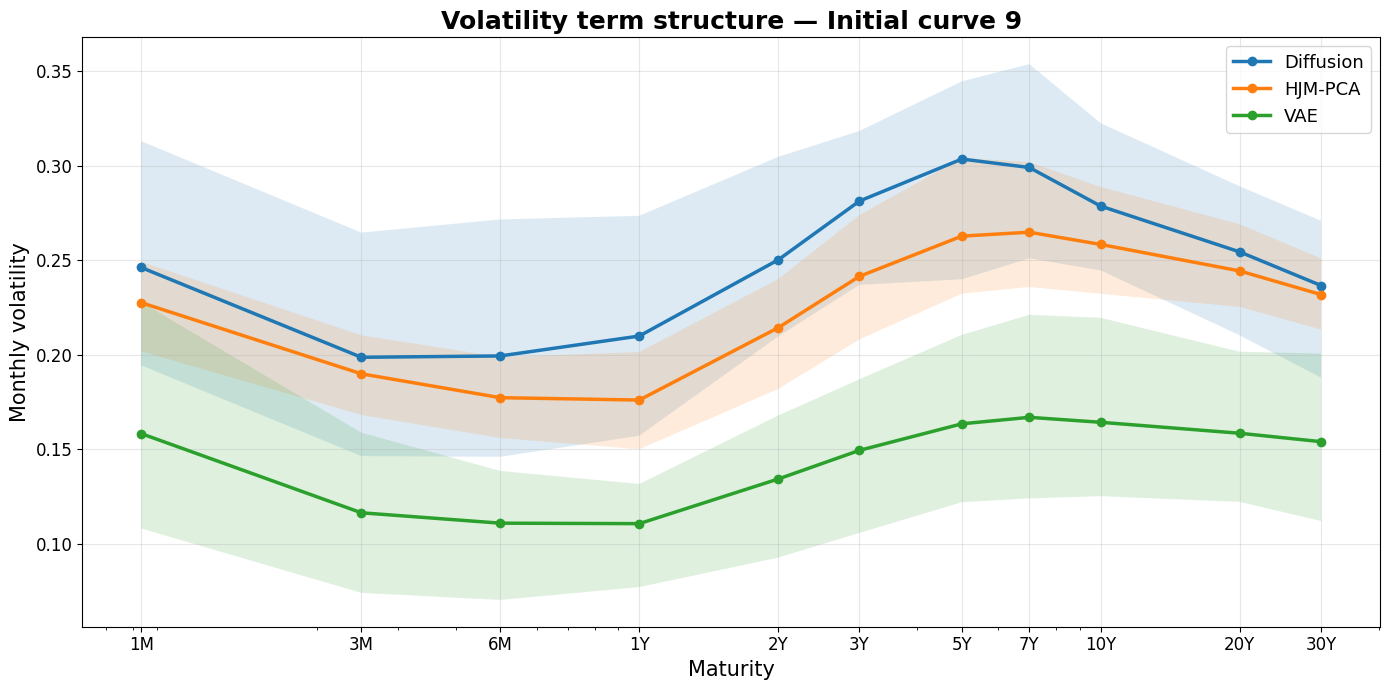

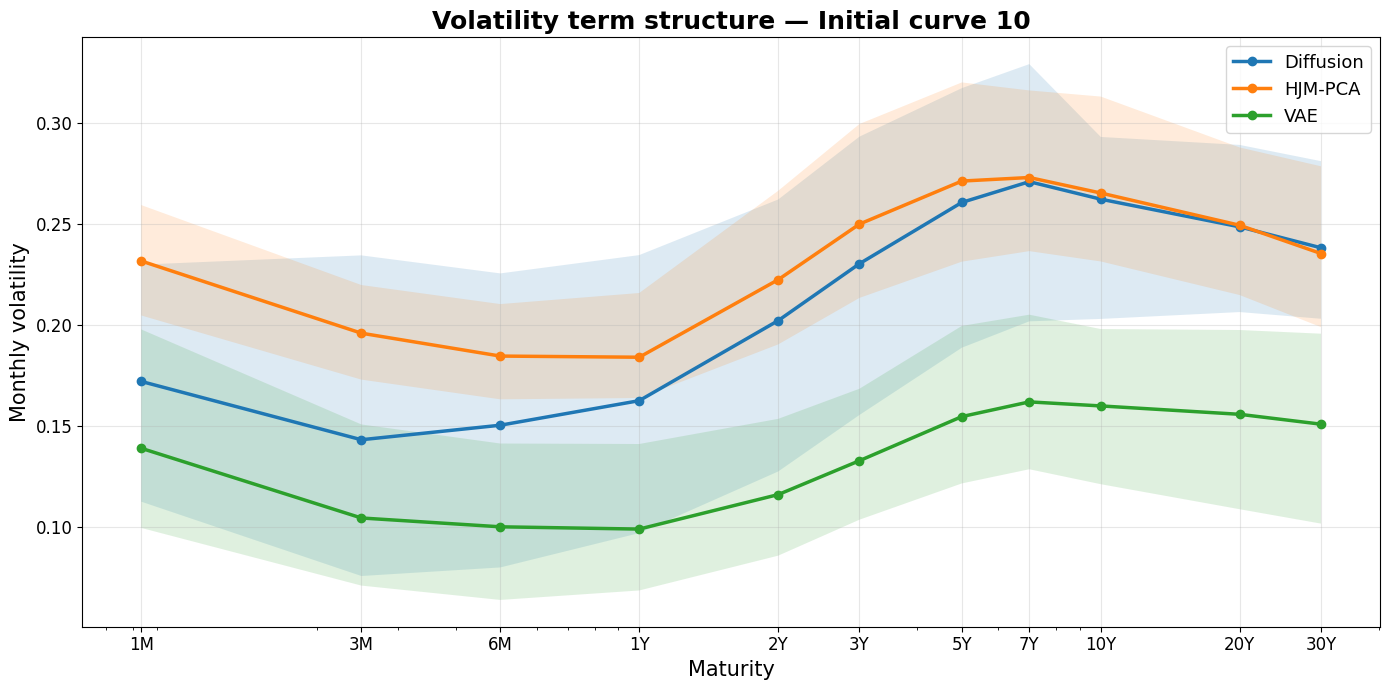

,Start_Curve_ID,Model,Maturity,Mean_Volatility
0,1,Diffusion,1M,0.245146
1,1,Diffusion,3M,0.195171
2,1,Diffusion,6M,0.188565
3,1,Diffusion,1Y,0.193876
4,1,Diffusion,2Y,0.229038


In [22]:
def volatility_by_maturity(tensor):
    # tensor shape: scenarios × months × maturities
    changes = np.diff(tensor, axis=1)
    scenario_vols = np.std(changes, axis=1, ddof=1)
    return scenario_vols


def plot_volatility_for_start_curve(start_curve_id):
    fig, ax = plt.subplots(figsize=(14, 7))

    summary_rows = []

    for model_name, df in SCENARIO_DATA.items():
        tensor, _ = scenario_tensor(df, start_curve_id)
        scenario_vols = volatility_by_maturity(tensor)

        mean_vol = scenario_vols.mean(axis=0)
        p05 = np.percentile(scenario_vols, 5, axis=0)
        p95 = np.percentile(scenario_vols, 95, axis=0)

        ax.plot(
            MATURITY_YEARS,
            mean_vol,
            marker="o",
            linewidth=2.5,
            label=model_name
        )
        ax.fill_between(MATURITY_YEARS, p05, p95, alpha=0.15)

        for maturity, mean_value in zip(MATURITY_LABELS, mean_vol):
            summary_rows.append({
                "Start_Curve_ID": start_curve_id,
                "Model": model_name,
                "Maturity": maturity,
                "Mean_Volatility": mean_value,
            })

    ax.set_xscale("log")
    ax.set_xticks(MATURITY_YEARS)
    ax.set_xticklabels(MATURITY_LABELS, fontsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_xlabel("Maturity", fontsize=15)
    ax.set_ylabel("Monthly volatility", fontsize=15)
    ax.set_title(
        f"Volatility term structure — Initial curve {start_curve_id}",
        fontsize=18,
        fontweight="bold"
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=13)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(summary_rows)


volatility_results = pd.concat(
    [plot_volatility_for_start_curve(start_id) for start_id in START_CURVE_IDS],
    ignore_index=True
)

volatility_results.head()


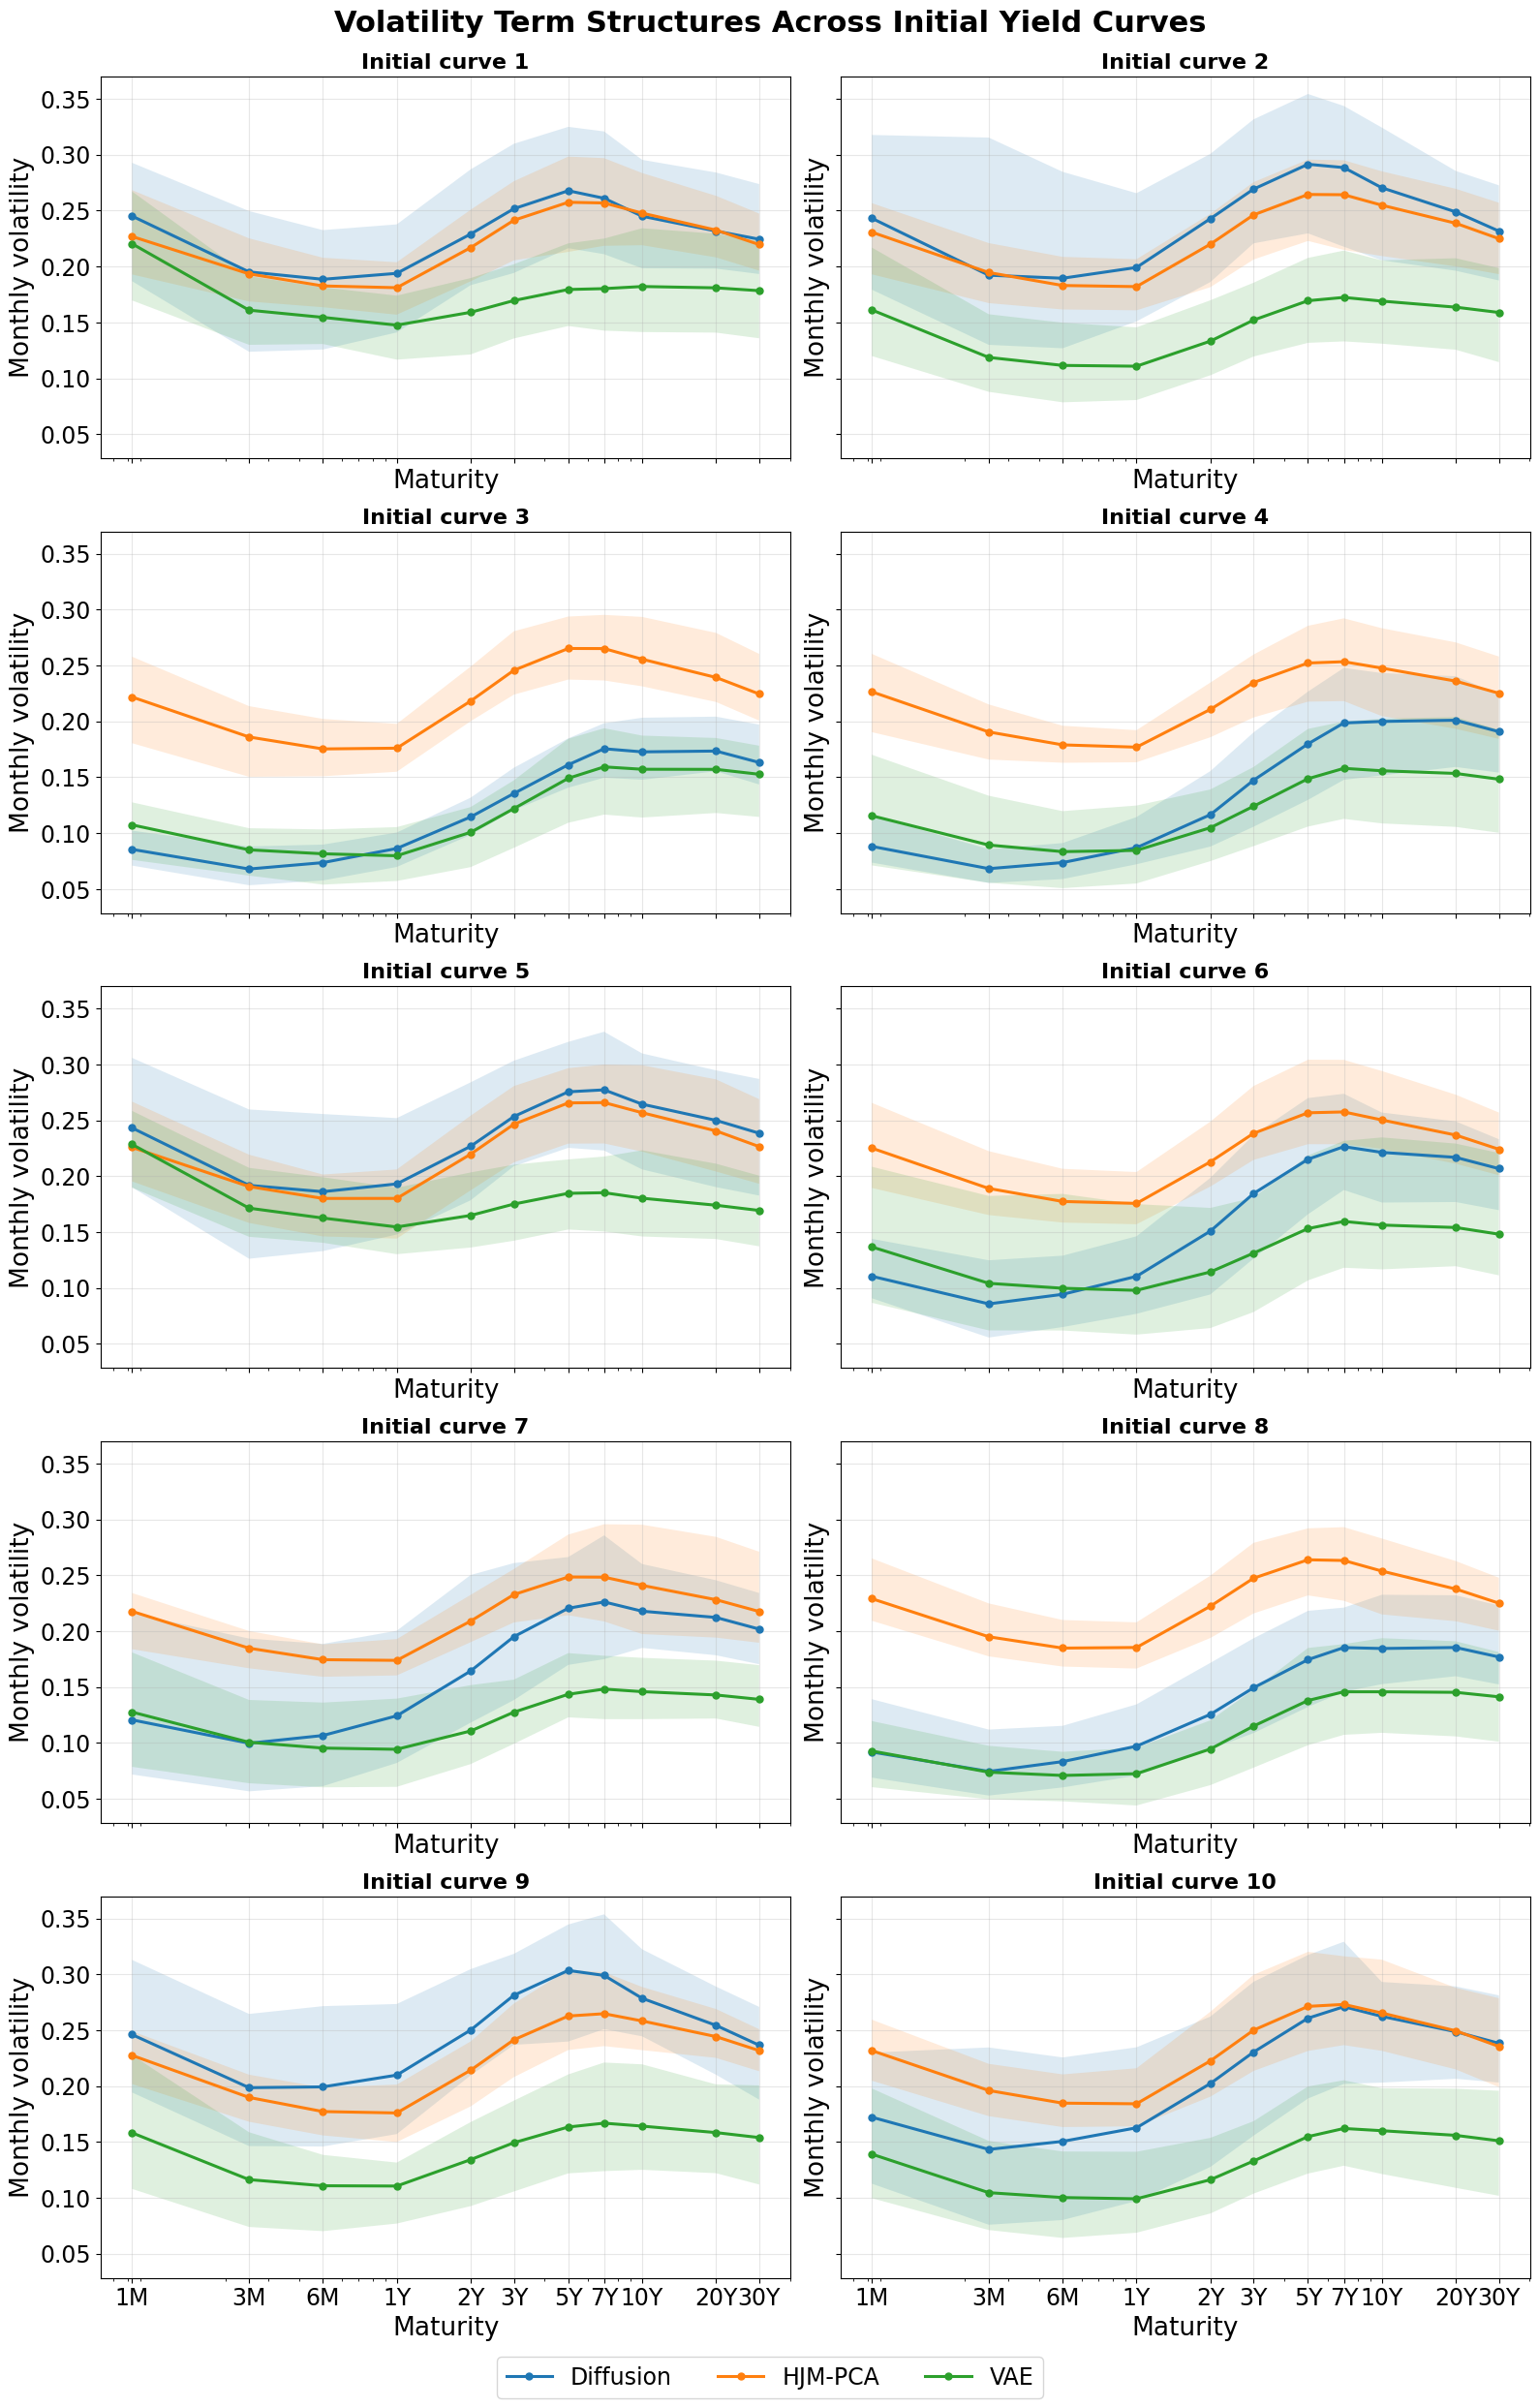

,Start_Curve_ID,Model,Maturity,Mean_Volatility
0,1,Diffusion,1M,0.245146
1,1,Diffusion,3M,0.195171
2,1,Diffusion,6M,0.188565
3,1,Diffusion,1Y,0.193876
4,1,Diffusion,2Y,0.229038


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Font sizes ──────────────────────────────────────────────────────────────
tick_fs = 17
axis_fs = 19
title_fs = 16
legend_fs = 17
suptitle_fs = 22

# ── Figure settings ─────────────────────────────────────────────────────────
n_rows = 5
n_cols = 2
figure_size = (16, 28)


def volatility_by_maturity(tensor):
    """
    tensor shape:
    scenarios × months × maturities
    """
    changes = np.diff(tensor, axis=1)

    scenario_vols = np.std(
        changes,
        axis=1,
        ddof=1
    )

    return scenario_vols


def plot_volatility_on_axis(ax, start_curve_id):
    """
    Plot one starting curve on an existing subplot axis.
    """

    summary_rows = []

    for model_name, df in SCENARIO_DATA.items():

        tensor, _ = scenario_tensor(
            df,
            start_curve_id
        )

        scenario_vols = volatility_by_maturity(tensor)

        mean_vol = scenario_vols.mean(axis=0)
        p05 = np.percentile(scenario_vols, 5, axis=0)
        p95 = np.percentile(scenario_vols, 95, axis=0)

        ax.plot(
            MATURITY_YEARS,
            mean_vol,
            marker="o",
            markersize=5,
            linewidth=2.2,
            label=model_name
        )

        ax.fill_between(
            MATURITY_YEARS,
            p05,
            p95,
            alpha=0.15
        )

        for maturity, mean_value in zip(
            MATURITY_LABELS,
            mean_vol
        ):
            summary_rows.append({
                "Start_Curve_ID": start_curve_id,
                "Model": model_name,
                "Maturity": maturity,
                "Mean_Volatility": mean_value
            })

    # ── Axis formatting ─────────────────────────────────────────────────────
    ax.set_xscale("log")

    ax.set_xticks(MATURITY_YEARS)
    ax.set_xticklabels(
        MATURITY_LABELS,
        fontsize=tick_fs
    )

    ax.tick_params(
        axis="y",
        labelsize=tick_fs
    )

    ax.set_xlabel(
        "Maturity",
        fontsize=axis_fs
    )

    ax.set_ylabel(
        "Monthly volatility",
        fontsize=axis_fs
    )

    ax.set_title(
        f"Initial curve {start_curve_id}",
        fontsize=title_fs,
        fontweight="bold"
    )

    ax.grid(alpha=0.3)

    return summary_rows


# ── Create 2 × 5 figure ─────────────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=figure_size,
    sharex=True,
    sharey=True
)

axes = axes.flatten()

all_summary_rows = []

for ax, start_curve_id in zip(
    axes,
    START_CURVE_IDS
):
    summary_rows = plot_volatility_on_axis(
        ax,
        start_curve_id
    )

    all_summary_rows.extend(summary_rows)


# Remove unused axes when fewer than 10 curves are present
for ax in axes[len(START_CURVE_IDS):]:
    ax.remove()


# ── One shared legend for the full figure ───────────────────────────────────
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=len(labels),
    fontsize=legend_fs,
    frameon=True
)


# ── Overall title ───────────────────────────────────────────────────────────
fig.suptitle(
    "Volatility Term Structures Across Initial Yield Curves",
    fontsize=suptitle_fs,
    fontweight="bold",
    y=0.935
)


# ── Layout ──────────────────────────────────────────────────────────────────
plt.tight_layout(
    rect=[0, 0.07, 1, 0.94]
)

# Optional:
# plt.savefig(
#     "volatility_term_structures_2x5.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()


# ── Results dataframe ───────────────────────────────────────────────────────
volatility_results = pd.DataFrame(all_summary_rows)

volatility_results.head()

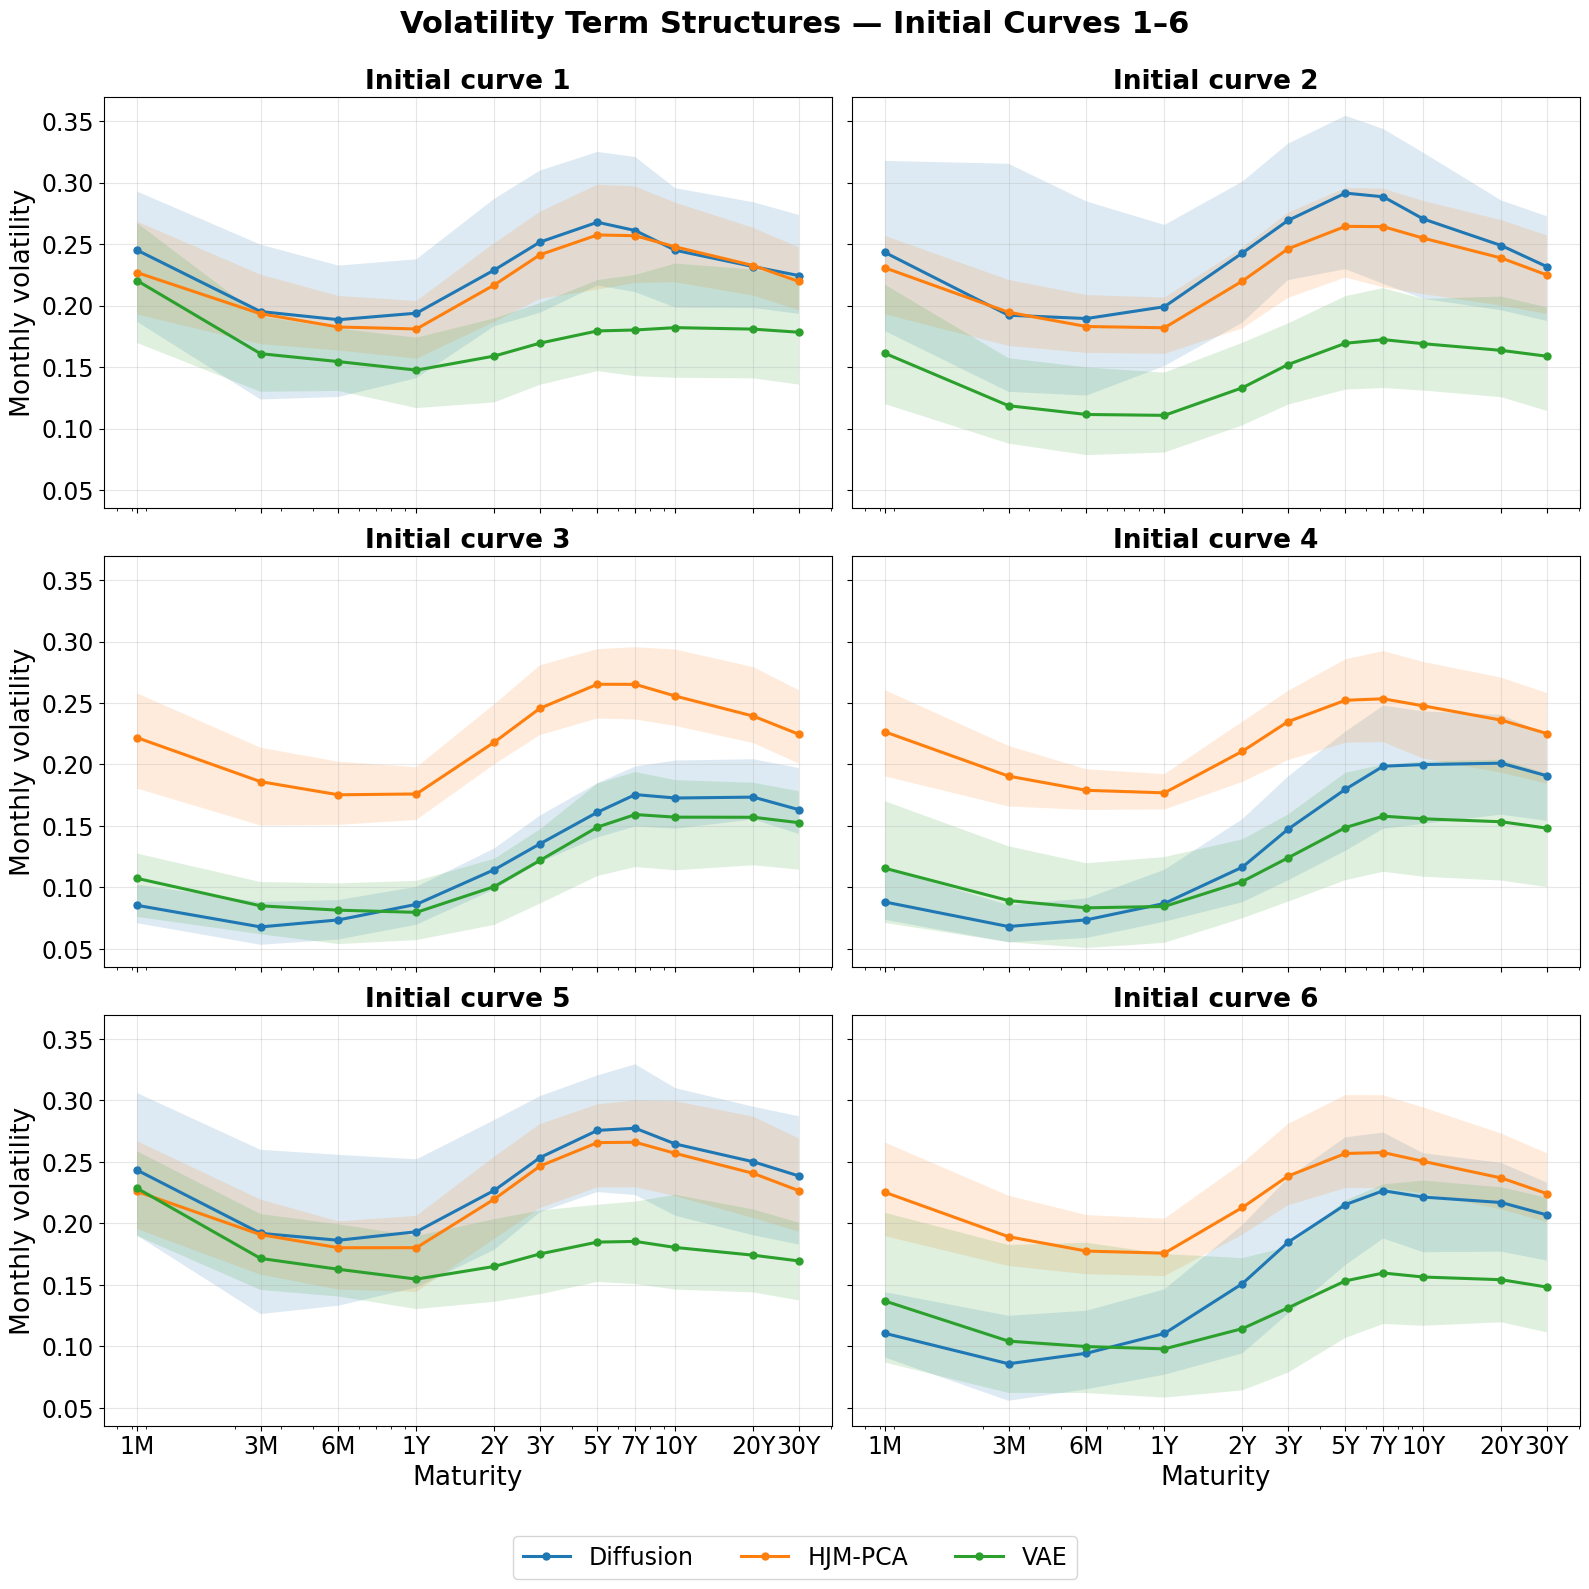

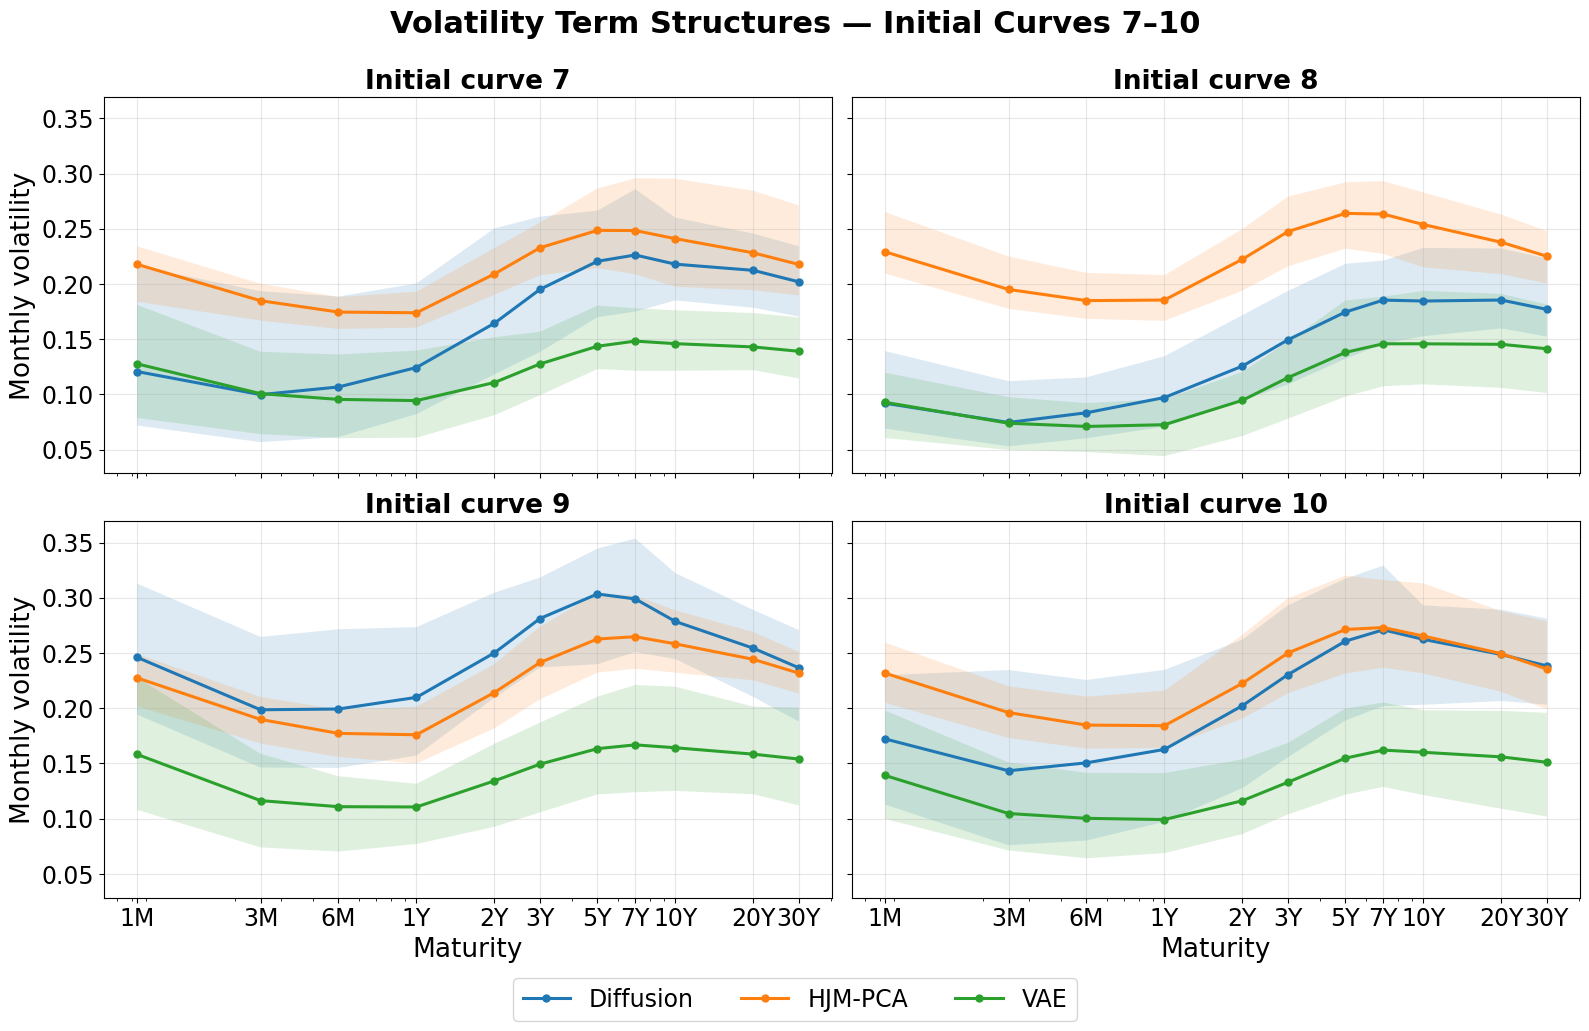

,Start_Curve_ID,Model,Maturity,Mean_Volatility
0,1,Diffusion,1M,0.245146
1,1,Diffusion,3M,0.195171
2,1,Diffusion,6M,0.188565
3,1,Diffusion,1Y,0.193876
4,1,Diffusion,2Y,0.229038


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Font sizes ──────────────────────────────────────────────────────────────
tick_fs = 17
axis_fs = 19
title_fs = 19
legend_fs = 17
suptitle_fs = 22

# ── Figure settings ─────────────────────────────────────────────────────────
figure_1_rows = 3
figure_1_cols = 2
figure_1_size = (16, 17)

figure_2_rows = 2
figure_2_cols = 2
figure_2_size = (16, 11)


def volatility_by_maturity(tensor):
    """
    tensor shape:
    scenarios × months × maturities
    """
    changes = np.diff(tensor, axis=1)

    scenario_vols = np.std(
        changes,
        axis=1,
        ddof=1
    )

    return scenario_vols


def plot_volatility_on_axis(
    ax,
    start_curve_id,
    row,
    col,
    n_rows
):
    """
    Plot one starting curve on an existing subplot axis.
    """

    summary_rows = []

    for model_name, df in SCENARIO_DATA.items():

        tensor, _ = scenario_tensor(
            df,
            start_curve_id
        )

        scenario_vols = volatility_by_maturity(tensor)

        mean_vol = scenario_vols.mean(axis=0)
        p05 = np.percentile(scenario_vols, 5, axis=0)
        p95 = np.percentile(scenario_vols, 95, axis=0)

        ax.plot(
            MATURITY_YEARS,
            mean_vol,
            marker="o",
            markersize=5,
            linewidth=2.2,
            label=model_name
        )

        ax.fill_between(
            MATURITY_YEARS,
            p05,
            p95,
            alpha=0.15
        )

        for maturity, mean_value in zip(
            MATURITY_LABELS,
            mean_vol
        ):
            summary_rows.append({
                "Start_Curve_ID": start_curve_id,
                "Model": model_name,
                "Maturity": maturity,
                "Mean_Volatility": mean_value
            })

    # ── Axis formatting ─────────────────────────────────────────────────────
    ax.set_xscale("log")

    ax.set_xticks(MATURITY_YEARS)
    ax.set_xticklabels(
        MATURITY_LABELS,
        fontsize=tick_fs
    )

    ax.tick_params(
        axis="both",
        labelsize=tick_fs
    )

    # X-axis title only on bottom row
    if row == n_rows - 1:
        ax.set_xlabel(
            "Maturity",
            fontsize=axis_fs
        )

    # Y-axis title only on left column
    if col == 0:
        ax.set_ylabel(
            "Monthly volatility",
            fontsize=axis_fs
        )

    ax.set_title(
        f"Initial curve {start_curve_id}",
        fontsize=title_fs,
        fontweight="bold"
    )

    ax.grid(alpha=0.3)

    return summary_rows


def plot_volatility_grid(
    start_curve_ids,
    n_rows,
    n_cols,
    figsize,
    figure_title
):
    """
    Create one volatility grid and return its summary rows.
    """

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=figsize,
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes).flatten()

    all_summary_rows = []

    for i, (ax, start_curve_id) in enumerate(
        zip(axes, start_curve_ids)
    ):
        row = i // n_cols
        col = i % n_cols

        summary_rows = plot_volatility_on_axis(
            ax=ax,
            start_curve_id=start_curve_id,
            row=row,
            col=col,
            n_rows=n_rows
        )

        all_summary_rows.extend(summary_rows)

    # Remove unused subplots
    for ax in axes[len(start_curve_ids):]:
        ax.remove()

    # ── Shared legend ───────────────────────────────────────────────────────
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=len(labels),
        fontsize=legend_fs,
        frameon=True
    )

    # ── Overall title ───────────────────────────────────────────────────────
    fig.suptitle(
        figure_title,
        fontsize=suptitle_fs,
        fontweight="bold",
        y=0.95
    )

    # ── Layout ──────────────────────────────────────────────────────────────
    plt.tight_layout(
        rect=[0, 0.07, 1, 0.95]
    )

    plt.show()

    return all_summary_rows


# ── First figure: first 6 start curves ──────────────────────────────────────
summary_rows_first_6 = plot_volatility_grid(
    start_curve_ids=START_CURVE_IDS[:6],
    n_rows=figure_1_rows,
    n_cols=figure_1_cols,
    figsize=figure_1_size,
    figure_title="Volatility Term Structures — Initial Curves 1–6"
)


# ── Second figure: last 4 start curves ──────────────────────────────────────
summary_rows_last_4 = plot_volatility_grid(
    start_curve_ids=START_CURVE_IDS[6:],
    n_rows=figure_2_rows,
    n_cols=figure_2_cols,
    figsize=figure_2_size,
    figure_title="Volatility Term Structures — Initial Curves 7–10"
)


# ── Combined results dataframe ──────────────────────────────────────────────
volatility_results = pd.DataFrame(
    summary_rows_first_6 + summary_rows_last_4
)

volatility_results.head()

## Vergelijking van gemiddelde volatiliteit per initiële curve


,Start_Curve_ID,Model,Mean_Volatility
0,1,Diffusion,0.230317
1,1,HJM-PCA,0.223319
2,1,VAE,0.173903
3,2,Diffusion,0.242462
4,2,HJM-PCA,0.227607
5,2,VAE,0.147339
6,3,Diffusion,0.128146
7,3,HJM-PCA,0.224828
8,3,VAE,0.122908
9,4,Diffusion,0.141033


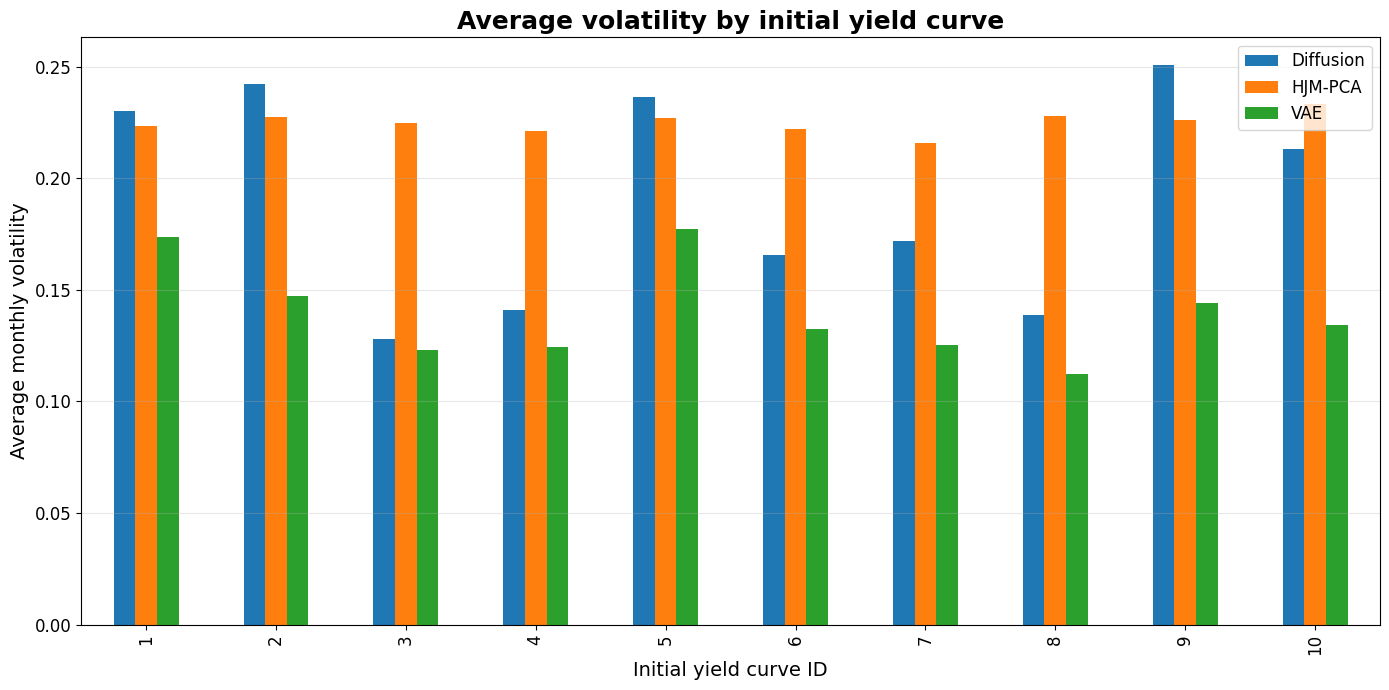

In [24]:
volatility_summary = (
    volatility_results
    .groupby(["Start_Curve_ID", "Model"], as_index=False)["Mean_Volatility"]
    .mean()
)

display(volatility_summary)

pivot = volatility_summary.pivot(
    index="Start_Curve_ID",
    columns="Model",
    values="Mean_Volatility"
)

ax = pivot.plot(kind="bar", figsize=(14, 7))
ax.set_title("Average volatility by initial yield curve", fontsize=18, fontweight="bold")
ax.set_xlabel("Initial yield curve ID", fontsize=14)
ax.set_ylabel("Average monthly volatility", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


for 1M rates

,Start_Curve_ID,Model,Mean_Volatility
0,1,Diffusion,0.245146
1,1,HJM-PCA,0.226892
2,1,VAE,0.220386
3,2,Diffusion,0.243217
4,2,HJM-PCA,0.230739
5,2,VAE,0.161200
6,3,Diffusion,0.085505
7,3,HJM-PCA,0.221827
8,3,VAE,0.107420
9,4,Diffusion,0.088199


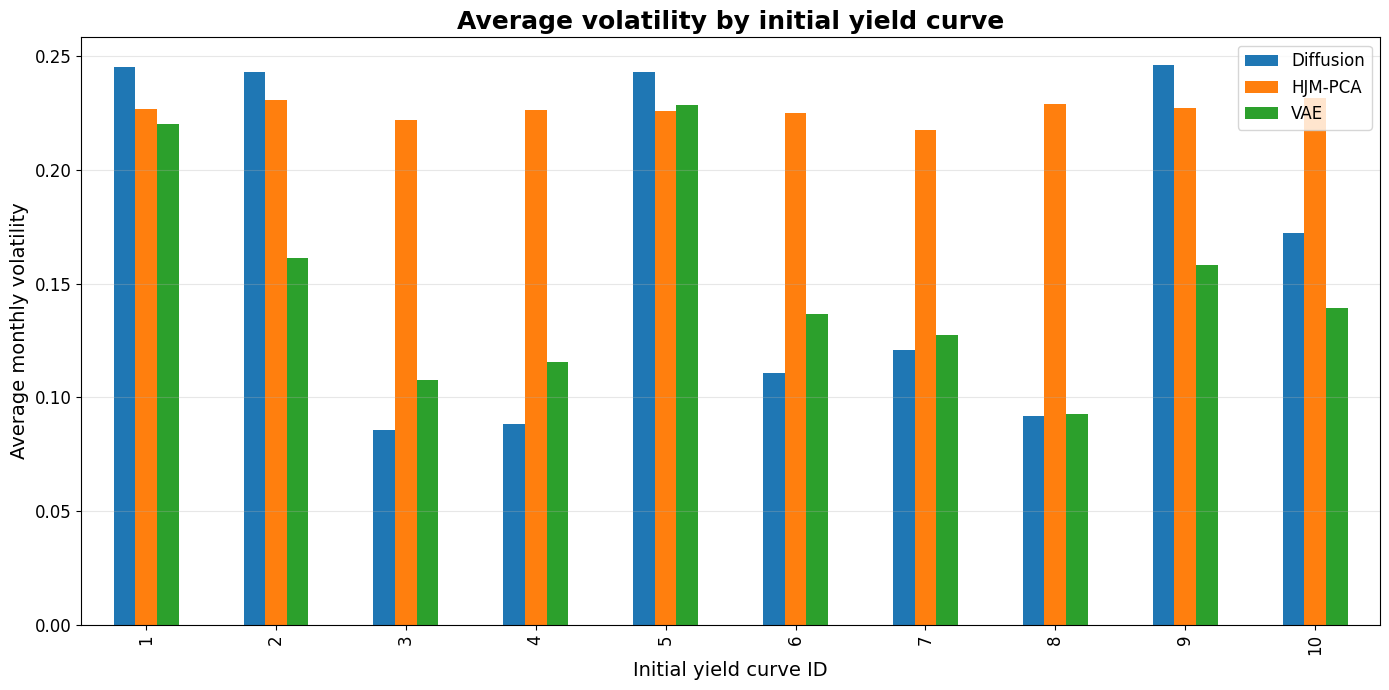

In [25]:
volatility_summary = (
    volatility_results[
        volatility_results["Maturity"] == "1M"
    ]
    .groupby(["Start_Curve_ID", "Model"], as_index=False)["Mean_Volatility"]
    .mean()
)

display(volatility_summary)

pivot = volatility_summary.pivot(
    index="Start_Curve_ID",
    columns="Model",
    values="Mean_Volatility"
)

ax = pivot.plot(kind="bar", figsize=(14, 7))
ax.set_title("Average volatility by initial yield curve", fontsize=18, fontweight="bold")
ax.set_xlabel("Initial yield curve ID", fontsize=14)
ax.set_ylabel("Average monthly volatility", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## Opslaan van resultaten


In [26]:
volatility_results.to_csv(
    "volatility_results_per_initial_curve.csv",
    index=False
)

volatility_summary.to_csv(
    "volatility_summary_per_initial_curve.csv",
    index=False
)

print("Resultaten opgeslagen.")


Resultaten opgeslagen.
